# Sélectionner le bon environnement de travail pour le python.

## Première étape : Collecte et enrichissement des données 

In [16]:
Visualization=False

Pour cette première étape, il nous semble tout d'abord nécessaire de récupérer tout d'abord les articles qui parle de Alzheimer.

Test appel API pour la plateforme arXiv :

In [2]:
import requests

# GET /query -- Search for papers on arXiv based on specific search criteria
url = "https://export.arxiv.org/query"
params = {"q": "machine learning", "max_results": 10}
search_criteria = requests.get(url, params=params)

# GET /abs/:id  -- Retrieve detailed information on a specific paper by its arXiv identifier.
url = "https://export.arxiv.org/abs/2003.10810"
specific_paper = requests.get(url)

# GET /list/:set -- Retrieve a list of papers based on specific criteria.
url = "https://export.arxiv.org/api/query"
params = {"search_query": "machine learning", "max_results": 10}
list_paper = requests.get(url, params=params)


if Visualization:
    print(f"{search_criteria.text}\n\n")
    print(f"{specific_paper.text}\n\n")
    print(f"{list_paper.text}\n\n")

Nous recherchons donc spécifiquement les sujets qui contiennent le terme "Alzheimer" dans un des champs de l'article (titre, sommaire, auteur,...).

In [ ]:
import requests
import time

time.sleep(3) # To respect arXiv's rate limits if cellule is run multiple time
max_research = 100

# Request to arXiv API to search for recent papers on Alzheimer's disease
url = "https://export.arxiv.org/api/query"
params = {
    "search_query": "all:Alzheimer",  # "all:" indicates search in all fields : title, abstract, authors, etc.
    "max_results": max_research, # number of results to return
    "sortBy": "lastUpdatedDate",      # order by last updated date
    "sortOrder": "descending"         # most recent first
}

response = requests.get(url, params=params)

# Display the response from arXiv API
if Visualization:
    print(response.text)

Le résultat obtenu est un XML, peu utilisable pour python. Nous allons donc utiliser feedparser pour rendre plus simple la manipulation des résultats et l'enregistrer sous la forme d'un .json

In [5]:
import feedparser
import time
feed = feedparser.parse(response.text)

# Extract of metadata
papers = []
for entry in feed.entries:
    time.sleep(2)
    id_article=entry.get("id").split("/abs/")[-1].split("v")[0]
    api_url=f"https://api.semanticscholar.org/graph/v1/paper/arXiv:{id_article}"
    params={
            "fields": "title,year,referenceCount,citationCount,influentialCitationCount,fieldsOfStudy,externalIds"
            }
    try:
        response = requests.get(api_url, params=params)
        if response.status_code != 200:
            time.sleep(3)
            response = requests.get(api_url, params=params)
            print("Error, status",response.status_code)
        link_citation=response.json()
        citation_nb=link_citation.get("citationCount", 0)
        reference_nb=link_citation.get("referenceCount", 0)
        recherche_sujet=link_citation.get("fieldsOfStudy","N/A")
        year_publication=link_citation.get("year")
    except:
        print("Erreur lors de la requête", response.status_code)

    papers.append({
        "arxiv_id": id_article,
        "title": entry.get("title"),
        "authors": [author.name for author in entry.authors],
        "published": entry.get("published"),
        "summary": entry.get("summary"),
        "link": entry.get("link"),
        "primary_category": entry.get("arxiv_primary_category", {}).get("term") if entry.get("arxiv_primary_category") else None,
        "categories": [tag["term"] for tag in entry.tags] if "tags" in entry else [],
        "citationCount":citation_nb,
        "referenceCount":reference_nb,
        "fieldsOfStudy":recherche_sujet,
        "year":year_publication
    })
print(f"Total papers found: {len(papers)} \n {'__'*40} \n")

# View the extracted metadata
if Visualization:
    for paper in papers:
        print(paper["arxiv_id"],
            paper["title"],
            paper["authors"],
            paper["published"], 
            paper["link"],
            paper["summary"],
            paper["categories"],
            paper["citationCount"],
            paper["referenceCount"],
            paper["fieldsOfStudy"],
            paper["year"],
        sep="\n")
        print()
        print("_"*20)

import json

with open("alzheimer_papers.json", "w") as f:
    json.dump(papers, f, indent=2)

Error, status 404
Error, status 429
Error, status 200
Error, status 200
Error, status 200
Error, status 200
Error, status 429
Error, status 429
Error, status 429
Error, status 429
Error, status 429
Error, status 429
Error, status 429
Error, status 200
Error, status 429
Error, status 200
Error, status 429
Error, status 429
Error, status 200
Error, status 429
Error, status 429
Error, status 200
Error, status 200
Error, status 429
Error, status 200
Error, status 200
Error, status 429
Error, status 200
Error, status 200
Error, status 429
Error, status 429
Error, status 429
Error, status 200
Error, status 200
Error, status 200
Error, status 429
Error, status 429
Error, status 200
Error, status 429
Error, status 429
Error, status 429
Error, status 429
Error, status 200
Error, status 200
Error, status 200
Error, status 200
Error, status 429
Error, status 429
Error, status 200
Error, status 200
Total papers found: 100 
 __________________________________________________________________________

Nous allons ajouté le nombre de références et le nombre de citations pour chaque article en utilisant la Semantic Scholar

In [6]:
from semanticscholar import SemanticScholar
client = SemanticScholar()
for paper in papers:
    paper_id=paper["arxiv_id"]
    try:
        paper_test = client.get_paper(f"ARXIV:{paper_id}", fields=["citationCount", "referenceCount", "fieldsOfStudy"])
        print(paper_test["citationCount"],paper_test["referenceCount"],paper_test["fieldsOfStudy"])
    except Exception as e:
        print("Erreur Semantic Scholar:", e)


Erreur Semantic Scholar: Paper with id ARXIV:2601.00143 not found
0 55 ['Computer Science']
0 31 ['Computer Science']
0 0 ['Mathematics']
31 44 ['Computer Science', 'Mathematics']
0 106 ['Computer Science']
0 107 ['Computer Science']
0 58 ['Computer Science']
0 88 ['Computer Science']
0 53 ['Mathematics']
0 42 ['Engineering']
0 49 ['Computer Science']
0 49 ['Computer Science']
0 45 ['Computer Science', 'Mathematics']
2 0 ['Computer Science']
0 37 ['Engineering', 'Computer Science']
0 42 ['Computer Science']
0 56 ['Computer Science']
0 70 ['Engineering', 'Computer Science']
0 62 ['Engineering']
0 24 ['Computer Science']
0 33 ['Computer Science']
0 58 ['Computer Science']
0 23 ['Mathematics']
0 42 ['Computer Science']
0 27 ['Engineering', 'Computer Science']
0 0 ['Biology', 'Computer Science']
0 57 ['Mathematics', 'Computer Science']
0 51 ['Biology']
0 1 ['Mathematics']
0 0 ['Engineering', 'Computer Science']
0 29 ['Medicine', 'Physics']
0 22 ['Engineering', 'Computer Science']
0 45 ['En

Ce premier trie peut cependant être largement améliorer. En effet, ce n'est pas parce que le terme "Alzheimer" est présent dans le titre ou le sommaire que l'article parle d'Alzheimer.

Prenons exemple suivant :

> "Robustness and sex differences in skin cancer detection: logistic regression vs CNNs ['Nikolette Pedersen', 'Regitze Sydendal', 'Andreas Wulff', 'Ralf Raumanns', 'Eike Petersen', 'Veronika Cheplygina'] 2025-10-01T09:38:25Z https://arxiv.org/abs/2504.11415v2"

Abstract :
>Deep learning has been reported to achieve high performances in the detection of skin cancer, yet many challenges regarding the reproducibility of results and biases remain. This study is a replication (different data, same analysis) of a previous study on **Alzheimer**'s disease detection, which studied the robustness of logistic regression (LR) and convolutional neural networks (CNN) across patient sexes. We explore sex bias in skin cancer detection, using the PAD-UFES-20 dataset with LR trained on handcrafted features reflecting dermatological guidelines (ABCDE and the 7-point checklist), and a pre-trained ResNet-50 model. We evaluate these models in alignment with the replicated study: across multiple training datasets with varied sex composition to determine their robustness. Our results show that both the LR and the CNN were robust to the sex distribution, but the results also revealed that the CNN had a significantly higher accuracy (ACC) and area under the receiver operating characteristics (AUROC) for male patients compared to female patients. The data and relevant scripts to reproduce our results are publicly available (this https URL nikodice4/Skin-cancer-detection-sex-bias).


L'abstract comporte bien le terme Alzheimer, mais le sujet principal de l'article concerne la robustesse entre des modèles de régressions logistiques et de CNN (Convolution Neural Network, convolution de réseau de neurone). 

Il existe plusieurs manières de revérifier si les articles concernés bien la maladie d'Alzheimer, notamment des modèles LLM - HuggingFace.
Nous voulons que sur l'ensemble des articles récupérées, les modèles vérifieront qu'il s'agit bien d'un article parlant de Alzheimer en effectuant une classification binaire.

#### Utilisation d'un LLM local Ollama

In [ ]:
%pip install ollama

In [17]:

import subprocess
import json

def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode(),
        capture_output=True
    )
    return result.stdout.decode().strip()

In [9]:
import subprocess
import json
from tqdm import tqdm

def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode(),
        capture_output=True
    )
    return result.stdout.decode().strip()

# Recuperation of data in alzheimer_papers.json
with open("alzheimer_papers.json", "r") as f:
    papers_json = json.load(f)

for i, paper in enumerate(tqdm(papers_json, desc="Ollama classification", unit="paper"),1):
    prompt = f"""
You are a biomedical research expert.

Read the following abstract carefully and answer with "yes" or "no".

Title:
{paper['title']}

Abstract:
{paper["summary"]}

Question:
Is the *main topic* of this article about Alzheimer's disease,
or about a method/approach directly related to diagnosing or treating Alzheimer's disease?

Important:
- If Alzheimer's disease is only mentioned briefly, or only as a previous study or comparison, answer "no".
- If the paper actually studies Alzheimer's disease, or proposes a diagnostic/treatment method for it, answer "yes".

"""


    response_text = ask_ollama(prompt)
    answer = response_text.strip().lower()

    paper["is_about_alzheimer"] = "yes" in answer
    if Visualization:
        print(f"[{i}/{len(papers_json)}] {paper['title']}")
        print(f"  → Answer: {answer}")
        print(f"  → Alzheimer-related: {paper['is_about_alzheimer']}")
        print("__" * 40)

print("Processing complete.")
print(f"Total papers analyzed: {len(papers_json)}")
print(f"Papers related to Alzheimer's disease: {sum(1 for p in papers_json if p['is_about_alzheimer'])}")

# Save the result
with open("papers_with_alzheimer_flag_ollama_1.json", "w") as f:
    json.dump(papers_json, f, indent=2)

Ollama classification:   0%|          | 0/100 [00:00<?, ?paper/s]

Ollama classification: 100%|██████████| 100/100 [00:33<00:00,  2.95paper/s]

Processing complete.
Total papers analyzed: 100
Papers related to Alzheimer's disease: 96


In [37]:
import json, requests
from tqdm import tqdm

URL = "http://localhost:11434/api/generate"
S = requests.Session()

def classify(paper):
    prompt = f"""You are a biomedical research expert.
Answer strictly "yes" or "no" plus ONE short sentence of reasoning.

Title:
{paper['title']}

Abstract:
{paper['summary']}

Question:
Is the main topic of this article Alzheimer's disease, or a method directly for diagnosing/treating Alzheimer's disease?

Rules:
- Brief mention/comparison only -> "no".
- Actual AD study or diagnostic/treatment for AD -> "yes"."""
    r = S.post(URL, json={
        "model":"gemma3:4b",
        "prompt": prompt,
        "stream": False,
        "keep_alive": "1h",
        "options": {"temperature":0, "num_predict":48}
    }, timeout=120)
    r.raise_for_status()
    resp = r.json()["response"].strip().lower()
    return ("yes" in resp), resp

with open("alzheimer_papers.json","r") as f:
    papers = json.load(f)

for p in tqdm(papers, desc="Ollama classification", unit="paper"):
    flag, raw = classify(p)
    p["is_about_alzheimer"] = flag
    p["ollama_raw"] = raw  # utile pour debug

with open("papers_with_alzheimer_flag_ollama_2.json","w") as f:
    json.dump(papers, f, indent=2)


Ollama classification:   0%|          | 0/100 [02:16<?, ?paper/s]


ReadTimeout: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=120)

Essayons d'améliorer le prompt pour qu'il comprenne des cas plus subtiles :

In [ ]:

test_no_Alzheimers_abstract = """
Deep learning has been reported to achieve high performances in the detection of skin cancer, yet many challenges regarding the reproducibility of results and biases remain. 
This study is a replication (different data, same analysis) of a previous study on Alzheimer's disease detection, which studied the robustness of logistic regression (LR) and convolutional neural networks (CNN) across patient sexes. 
We explore sex bias in skin cancer detection, using the PAD-UFES-20 dataset with LR trained on handcrafted features reflecting dermatological guidelines (ABCDE and the 7-point checklist), and a pre-trained ResNet-50 model. 
We evaluate these models in alignment with the replicated study: across multiple training datasets with varied sex composition to determine their robustness. 
Our results show that both the LR and the CNN were robust to the sex distribution, but the results also revealed that the CNN had a significantly higher accuracy (ACC) and area under the receiver operating characteristics (AUROC) for male patients compared to female patients. 
The data and relevant scripts to reproduce our results are publicly available (this https URL nikodice4/Skin-cancer-detection-sex-bias)."""

prompt = f"""
        You are an expert in biomedical research. 
        Read the following abstract and answer strictly with "yes" or "no".

        Abstract:
        {test_no_Alzheimers_abstract}

        Question:
        Does this article discuss Alzheimer's disease, or a method/approach related to diagnosing or treating Alzheimer's disease?
        Answer with "yes" or "no" and explain briefly your reasoning.
        """
response_text = ask_ollama(prompt)
answer = response_text.strip().lower()
print(f"Test Abstract Answer: {answer}")


Test Abstract Answer: no - the abstract explicitly states this study is a replication of a previous alzheimer's disease detection study, focusing on comparing logistic regression and cnns across patient sexes, rather than directly investigating alzheimer's disease itself.


Retestons donc avec ce nouveau prompt

In [ ]:
import subprocess
import json

def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode(),
        capture_output=True
    )
    return result.stdout.decode().strip()

for i, paper in enumerate(papers_json, 1):
    prompt = f"""
    You are a biomedical research expert.

    Your task is to determine whether the *main focus* of the following abstract is related to Alzheimer's disease or its diagnosis or treatment.

    Important:
    - If Alzheimer's disease is only mentioned for comparison, or as a reference to previous work, the answer must be "no".
    - Answer strictly with "yes" or "no" (no explanations).

    Title:
    {paper['title']}

    Abstract:
    {test_no_Alzheimers_abstract}

    Question:
    Is this article about Alzheimer's disease, or about a method/approach related to diagnosing or treating Alzheimer's disease?
    """

    response_text = ask_ollama(prompt)
    answer = response_text.strip().lower()

    paper["is_about_alzheimer"] = "yes" in answer

    print(f"[{i}/{len(papers)}] {paper['title']}")
    print(f"  → Answer: {answer}")
    print(f"  → Alzheimer-related: {paper['is_about_alzheimer']}")
    print("__" * 40)

print("Processing complete.")
print(f"Total papers analyzed: {len(papers)}")
print(f"Papers related to Alzheimer's disease: {sum(1 for p in papers if p['is_about_alzheimer'])}")

# Save the result
with open("papers_with_alzheimer_flag_ollama_2.json", "w") as f:
    json.dump(papers, f, indent=2)

Maintenant que tout a bien été structuré, nous pouvons le conserver localement

In [9]:
import pandas as pd

df = pd.DataFrame(papers)
# Sort by published date descending
df = df.sort_values("published", ascending=False)
df.head()


,title,authors,published,summary,link
0,A Robust Classification Method using Hybrid Wo...,[Yangyang Li],2025-10-16T06:10:31Z,Early detection of Alzheimer's Disease (AD) is...,http://arxiv.org/abs/2510.14332v1
1,Working Memory Functional Connectivity Analysi...,"[Shivani Ranjan, Anant Jain, Robin Badal, Amit...",2025-10-15T10:52:48Z,"Background: Dementia, particularly Alzheimer's...",http://arxiv.org/abs/2510.13399v1
4,Non-linear associations of amyloid-$β$ with re...,"[Junjie Wu, Benjamin B Risk, Taylor A James, N...",2025-10-14T17:32:39Z,Background: Non-linear alterations in brain ne...,http://arxiv.org/abs/2510.12751v1
5,From Knowledge to Treatment: Large Language Mo...,"[Chengrui Xiang, Tengfei Ma, Xiangzheng Fu, Yi...",2025-10-14T06:15:36Z,Drug repurposing plays a critical role in acce...,http://arxiv.org/abs/2510.12181v1
6,Variational Mixture of Graph Neural Experts fo...,"[Jun-En Ding, Anna Zilverstand, Shihao Yang, A...",2025-10-13T20:37:18Z,Dementia disorders such as Alzheimer's disease...,http://arxiv.org/abs/2510.11917v1


Nous allons également le sauvegarder en JSON pour le relire plus tard lors de demande API d'un LLM

On pourrait aller encore plus loin en utilisant SQLite

Le soucis principal avec un LLM en local de ce type, c'est qu'il réalise des erreurs de compréhension. En effet, un tel LLM est entraîné sur des textes brutes, qui ne comporte peu de vocabulaire médicale. Il existe cependant d'autres modèles pré-entrainé sur des données médicales.

### Utilisation d'un modèle HuggingFace

La plateforme HuggingFace propose des modèles qui ont été entrainés sur des articles médicaux, parfait pour notre cas.

Nous avons ainsi :
- BioBERT (dmis-lab/biobert-base-cased-v1.1)
- SciBERT (allenai/scibert_scivocab_uncased)
- BioClinicalBERT (emilyalsentzer/Bio_ClinicalBERT)
- PubMedBERT (microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext)

Avant tout de chose, il faut installer localement les modèles pour les appeler plus rapidement par la suite. En effet, si le réseau est mauvais, nous pourrons toujours utiliser les modèles.

Pour se faire, nous allons autoriser Jupyter à accéder aux transformers de manière offline.

In [2]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "0"


In [3]:
!hf download allenai/scibert_scivocab_uncased
!hf download dmis-lab/biobert-base-cased-v1.1
!hf download emilyalsentzer/Bio_ClinicalBERT
!hf download microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract

Fetching 6 files: 100%|█████████████████████████| 6/6 [00:00<00:00, 5488.73it/s]
/home/ben/.cache/huggingface/hub/models--allenai--scibert_scivocab_uncased/snapshots/24f92d32b1bfb0bcaf9ab193ff3ad01e87732fc1
Fetching 4 files: 100%|█████████████████████████| 4/4 [00:00<00:00, 4512.43it/s]
/home/ben/.cache/huggingface/hub/models--dmis-lab--biobert-base-cased-v1.1/snapshots/924f12e0c3db7f156a765ad53fb6b11e7afedbc8
Fetching 12 files: 100%|█████████████████████| 12/12 [00:00<00:00, 30211.07it/s]
/home/ben/.cache/huggingface/hub/models--emilyalsentzer--Bio_ClinicalBERT/snapshots/d5892b39a4adaed74b92212a44081509db72f87b
Fetching 8 files: 100%|████████████████████████| 8/8 [00:00<00:00, 59074.70it/s]
/home/ben/.cache/huggingface/hub/models--microsoft--BiomedNLP-PubMedBERT-base-uncased-abstract/snapshots/d673b8835373c6fa116d6d8006b33d48734e305d


In [8]:
!pip freeze | grep -i -E "tensor|keras|jax|flax"

keras==3.11.3
safetensors==0.6.2
tensorboard==2.20.0
tensorboard-data-server==0.7.2
tensorflow==2.20.0
tf_keras==2.20.1


Après les avoir mis ainsi en cache, plus besoin de les installer. Précisons à Jupyter qu'il n'a plus besoin d'installer les transformers depuis internet.

In [4]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


### Modèle BioBERT de Hugging Face

In [29]:
# Load model directly
from transformers import AutoModel

from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import json

# Charge SciBERT
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
model_BioBERT = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1", dtype="auto")


# Function to get embedding
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model_BioBERT(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding

# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_BioBERT = json.load(f)


Exception ignored in: <function tqdm.__del__ at 0x7f8699dd8820>
Traceback (most recent call last):
  File "/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


In [ ]:
# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_BioBERT = json.load(f)
    
# Similarity threshold
value_similarity_threshold = 0.80

# Reference embedding (mot-clé Alzheimer)
ref_text = "This article is about Alzheimer's disease or a treatment/diagnostic of Alzheimer's disease."
ref_embedding = get_embedding(ref_text)

# Similarity computation
cos = torch.nn.CosineSimilarity(dim=0)

for i, paper in enumerate(tqdm(papers_json_BioBERT, desc="Bio_BERT classification", unit="paper"), 1):
    abs_embedding = get_embedding(paper["summary"])
    similarity = cos(ref_embedding, abs_embedding).item()
    
    # Empiric threshold to adjust based on your tests
    paper["similarity"] = similarity
    paper["is_about_alzheimer"] = similarity > value_similarity_threshold

    if Visualization: 
        print(f"[{i}/{len(papers_json_BioBERT)}] {paper['title']}")
        print(f"  → Similarity: {similarity:.3f}")
        print(f"  → Alzheimer-related: {paper['is_about_alzheimer']}")
        print("__" * 40)

# Sauvegarde
with open("papers_with_alzheimer_flag_Bio_BERT.json", "w") as f:
    json.dump(papers_json_BioBERT, f, indent=2)

print("Processing complete")
print(f"Total papers analyzed: {len(papers_json_BioBERT)}")
print(f"Papers related to Alzheimer's disease: {sum(1 for p in papers_json_BioBERT if p['is_about_alzheimer'])}")


### Modèle SciBERT 
Modèle provenant de :

@inproceedings{beltagy-etal-2019-scibert,
    title = "SciBERT: A Pretrained Language Model for Scientific Text",
    author = "Beltagy, Iz  and Lo, Kyle  and Cohan, Arman",
    booktitle = "EMNLP",
    year = "2019",
    publisher = "Association for Computational Linguistics",
    url = "https://www.aclweb.org/anthology/D19-1371"
}

In [7]:
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import json

# Charge SciBERT
tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")
model_SciBERT = AutoModel.from_pretrained("allenai/scibert_scivocab_uncased", dtype="auto")

# Function to get embedding
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model_SciBERT(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding

# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_SciBERT = json.load(f)


In [ ]:
# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_SciBERT = json.load(f)
    
# Similarity threshold
value_similarity_threshold = 0.8

# Reference embedding (mot-clé Alzheimer)
ref_text = "This article is about Alzheimer's disease or a treatment/diagnostic of Alzheimer's disease."
ref_embedding = get_embedding(ref_text)

# Similarity computation
cos = torch.nn.CosineSimilarity(dim=0)

for i, paper in enumerate(tqdm(papers_json_SciBERT, desc="SciBERT classification", unit="paper"), 1):
    abs_embedding = get_embedding(paper["summary"])
    similarity = cos(ref_embedding, abs_embedding).item()
    
    # Empiric threshold to adjust based on your tests
    paper["similarity"] = similarity
    paper["is_about_alzheimer"] = similarity > value_similarity_threshold

    if Visualization: 
        print(f"[{i}/{len(papers_json_SciBERT)}] {paper['title']}")
        print(f"  → Similarity: {similarity:.3f}")
        print(f"  → Alzheimer-related: {paper['is_about_alzheimer']}")
        print("__" * 40)

# Save
with open("papers_with_alzheimer_flag_SciBERT.json", "w") as f:
    json.dump(papers_json_SciBERT, f, indent=2)

print("Processing complete")
print(f"Total papers analyzed: {len(papers_json_SciBERT)}")
print(f"Papers related to Alzheimer's disease: {sum(1 for p in papers_json_SciBERT if p['is_about_alzheimer'])}")


SciBERT classification: 100%|██████████| 100/100 [00:16<00:00,  6.17paper/s]

Processing complete ✅
Total papers analyzed: 100
Papers related to Alzheimer's disease: 100


### Modèle BioClinicalBERT (emilyalsentzer/Bio_ClinicalBERT)


In [4]:
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import json

# Charge BioClinicalBERT
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model_BioClinicalBERT = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT", dtype="auto")

# Function to get embedding
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model_BioClinicalBERT(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding

# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_BioClinicalBERT = json.load(f)


2025-10-31 10:59:49.557761: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-31 10:59:55.972941: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-31 11:00:31.237380: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Exception ignored in: <function tqdm.__del__ at 0x7fcd785d4ca0>
Traceback (most recent call

In [ ]:
# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_BioClinicalBERT = json.load(f)
    
# Similarity threshold
value_similarity_threshold = 0.8

# Reference embedding (mot-clé Alzheimer)
ref_text = "This article is about Alzheimer's disease or a treatment/diagnostic of Alzheimer's disease."
ref_embedding = get_embedding(ref_text)

# Similarity computation
cos = torch.nn.CosineSimilarity(dim=0)

for i, paper in enumerate(tqdm(papers_json_BioClinicalBERT, desc="BioClinicalBERT classification", unit="paper"), 1):
    abs_embedding = get_embedding(paper["summary"])
    similarity = cos(ref_embedding, abs_embedding).item()
    
    # Empiric threshold to adjust based on your tests
    paper["similarity"] = similarity
    paper["is_about_alzheimer"] = similarity > value_similarity_threshold

    if Visualization: 
        print(f"[{i}/{len(papers_json_BioClinicalBERT)}] {paper['title']}")
        print(f"  → Similarity: {similarity:.3f}")
        print(f"  → Alzheimer-related: {paper['is_about_alzheimer']}")
        print("__" * 40)

# Save
with open("papers_with_alzheimer_flag_BioClinicalBERT.json", "w") as f:
    json.dump(papers_json_BioClinicalBERT, f, indent=2)

print("Processing complete")
print(f"Total papers analyzed: {len(papers_json_BioClinicalBERT)}")
print(f"Papers related to Alzheimer's disease: {sum(1 for p in papers_json_BioClinicalBERT if p['is_about_alzheimer'])}")


BioClinicalBERT classification: 100%|██████████| 100/100 [00:17<00:00,  5.81paper/s]

Processing complete ✅
Total papers analyzed: 100
Papers related to Alzheimer's disease: 100


### PubMedBERT (microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext)

In [6]:
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import json

# Charge PubMedBERT
tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext")
model_PubMedBERT = AutoModel.from_pretrained("microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext", dtype="auto")

# Function to get embedding
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model_PubMedBERT(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding

# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_PubMedBERT = json.load(f)


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

  2025-10-31T10:01:22.829680Z ERROR  Python exception updating progress:, error: PyErr { type: <class 'LookupError'>, value: LookupError(<ContextVar name='shell_parent' at 0x7fcd8a562250>), traceback: Some(<traceback object at 0x7fcc1c927a00>) }, caller: "src/progress_update.rs:313"
    at /home/runner/work/xet-core/xet-core/error_printer/src/lib.rs:28



Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
# Charge articles
with open("alzheimer_papers.json", "r") as f:
    papers_json_PubMedBERT = json.load(f)
    
# Similarity threshold
value_similarity_threshold = 0.8

# Reference embedding (mot-clé Alzheimer)
ref_text = "This article is about Alzheimer's disease or a treatment/diagnostic of Alzheimer's disease."
ref_embedding = get_embedding(ref_text)

# Similarity computation
cos = torch.nn.CosineSimilarity(dim=0)

for i, paper in enumerate(tqdm(papers_json_PubMedBERT, desc="PubMedBERT classification", unit="paper"), 1):
    abs_embedding = get_embedding(paper["summary"])
    similarity = cos(ref_embedding, abs_embedding).item()
    
    # Empiric threshold to adjust based on your tests
    paper["similarity"] = similarity
    paper["is_about_alzheimer"] = similarity > value_similarity_threshold

    if Visualization: 
        print(f"[{i}/{len(papers_json_PubMedBERT)}] {paper['title']}")
        print(f"  → Similarity: {similarity:.3f}")
        print(f"  → Alzheimer-related: {paper['is_about_alzheimer']}")
        print("__" * 40)

# Save
with open("papers_with_alzheimer_flag_PubMedBERT.json", "w") as f:
    json.dump(papers_json_PubMedBERT, f, indent=2)

print("Processing complete")
print(f"Total papers analyzed: {len(papers_json_PubMedBERT)}")
print(f"Papers related to Alzheimer's disease: {sum(1 for p in papers_json_PubMedBERT if p['is_about_alzheimer'])}")


### Données finales
Une chose est sûre, peu importe le modèle que nous prendrons, il faut enlever les données non pertinentes

In [10]:
# Suppress data false
# for papers_with_alzheimer_flag_ollama_1.json
import json
with open("papers_with_alzheimer_flag_ollama_1.json", "r") as f:
    papers_data = json.load(f)
filtered_papers = [paper for paper in papers_data if paper.get("is_about_alzheimer")]
with open("papers_with_alzheimer_flag_ollama_1_filtered.json", "w") as f:
    json.dump(filtered_papers, f, indent=2)

In [1]:
import json
import os
import re
import requests
from tqdm import tqdm

# === Paramètres ===
json_path = "papers_with_alzheimer_flag_ollama_1_filtered.json"
output_dir = "pdfs"
os.makedirs(output_dir, exist_ok=True)

# === Chargement du JSON ===
with open(json_path, "r", encoding="utf-8") as file:
    data = json.load(file)

# === Extraction et téléchargement ===
for art in tqdm(data, desc="Téléchargement des PDF"):
    link = art.get("link", "")
    if not link or "arxiv.org/abs/" not in link:
        continue
    
    # Récupération de l'identifiant arXiv
    match = re.search(r"arxiv\.org/abs/([\w\.\-]+)", link)
    if not match:
        continue
    arxiv_id = match.group(1)

    pdf_url = f"https://arxiv.org/pdf/{arxiv_id}.pdf"
    pdf_path = os.path.join(output_dir, f"{arxiv_id}.pdf")

    # Si déjà téléchargé, on passe
    if os.path.exists(pdf_path):
        continue

    try:
        response = requests.get(pdf_url, timeout=20)
        if response.status_code == 200 and response.headers.get("Content-Type", "").startswith("application/pdf"):
            with open(pdf_path, "wb") as f:
                f.write(response.content)
        else:
            print(f"⚠️ Échec téléchargement pour {pdf_url} (code {response.status_code})")
    except Exception as e:
        print(f"❌ Erreur pour {pdf_url} : {e}")


Téléchargement des PDF: 100%|██████████| 96/96 [04:34<00:00,  2.86s/it]


## Seconde étape : Regroupement des articles

Ici, notre but est de regrouper les articles selon leurs sujets. Mais des questions se posent donc : Combien de groupes d'articles voulons-nous ? et quel serait le nombre le plus adéquat ?
Une solution simple serait de prendre les catégories de tous les articles préexistants et de les regrouper ainsi.


In [1]:
import json

json_path = "papers_with_alzheimer_flag_ollama_1_filtered.json"

with open(json_path, "r", encoding="utf-8") as file:
    data = json.load(file)

categorie={}
for paper in data:
    premiery_category=paper["primary_category"].split(".")[0]
    print(paper['arxiv_id'], paper['primary_category'])
    if premiery_category in categorie:
        categorie[premiery_category]["nombre"]+=1
        categorie[premiery_category]["papers"].append(paper["arxiv_id"])
    else:
        categorie[premiery_category]={
            "name":premiery_category,
            "nombre":1,
            "papers":[paper["arxiv_id"]]
    }
    
print("Catégories trouvées :",categorie.keys())
print("Nombre de catégories :",len(categorie))


2601.00143 q-bio.GN
2512.23441 cs.LG
2512.23093 cs.HC
2506.16668 stat.ME
2210.13327 stat.ML
2512.20948 cs.CL
2502.06842 cs.CY
2512.19099 cs.LG
2512.18986 cs.LG
2512.18403 stat.ME
2508.18712 eess.SP
2508.20717 cs.SD
2512.17276 cs.LG
2505.11622 stat.ML
2506.09695 cs.CV
2512.16964 eess.IV
2512.16184 cs.LG
2509.21735 cs.LG
2512.15947 eess.IV
2512.15246 eess.SP
2512.14491 cs.AI
2512.14026 cs.CV
2512.13685 cs.CL
2512.13346 stat.AP
2512.13747 cs.CV
2405.13199 eess.IV
2512.13724 q-bio.QM
2512.10716 math.NA
2511.18238 q-bio.QM
2512.09217 stat.AP
2412.01865 eess.IV
2512.07061 physics.med-ph
2507.01794 eess.IV
2512.06134 cs.LG
2512.05814 cs.CV
2301.03057 stat.ME
2512.10981 q-bio.NC
2512.04937 q-bio.MN
2512.03912 stat.ME
2512.03467 cs.LG
2408.12618 stat.AP
2511.01732 stat.AP
2512.01367 cs.LG
2512.05993 cs.CV
2512.10966 cs.LG
2512.00269 cs.CV
2511.22774 cs.CV
2511.22102 cs.CV
2511.21530 cs.CV
2511.21114 cs.CV
2511.21057 cs.CV
2511.20154 cs.CV
2505.24166 eess.IV
2508.17171 cs.CV
2511.20704 cs.LG
251


Bien entendu, il existe manière d'autres :
Réaliser un Clustering de données

## Vectorisation

Avant de clusteriser, il transformer nos textes en vecteurs.

In [1]:
import os
import json
import fitz  # PyMuPDF
from tqdm import tqdm
import pandas as pd
#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score
#from sentence_transformers import SentenceTransformer


In [2]:

# === Fichiers ===
json_path = "papers_with_alzheimer_flag_ollama_1_filtered.json"
pdf_dir = "pdfs"

# === 1. Chargement du JSON ===
with open(json_path, "r", encoding="utf-8") as file:
    data = json.load(file)


In [3]:

# === 2. Fonction pour extraire le texte d'un PDF ===
def extract_text_from_pdf(pdf_path, max_pages=None):
    try:
        text = ""
        with fitz.open(pdf_path) as doc:
            for i, page in enumerate(doc):
                if max_pages and i >= max_pages:
                    break
                text += page.get_text("text")
        return text.strip()
    except Exception as e:
        print(f"⚠️ Erreur lecture {pdf_path}: {e}")
        return ""


In [4]:
print(data)

[{'arxiv_id': '2601.00143', 'title': "MethConvTransformer: A Deep Learning Framework for Cross-Tissue Alzheimer's Disease Detection", 'authors': ['Gang Qu', 'Guanghao Li', 'Zhongming Zhao'], 'published': '2026-01-01T00:18:33Z', 'summary': "Alzheimer's disease (AD) is a multifactorial neurodegenerative disorder characterized by progressive cognitive decline and widespread epigenetic dysregulation in the brain. DNA methylation, as a stable yet dynamic epigenetic modification, holds promise as a noninvasive biomarker for early AD detection. However, methylation signatures vary substantially across tissues and studies, limiting reproducibility and translational utility. To address these challenges, we develop MethConvTransformer, a transformer-based deep learning framework that integrates DNA methylation profiles from both brain and peripheral tissues to enable biomarker discovery. The model couples a CpG-wise linear projection with convolutional and self-attention layers to capture local 

In [10]:
# === 3. Construction des textes enrichis ===
texts = []
for art in tqdm(data, desc="Préparation des textes"):
    link = art.get("link", "")

    # retrouver l'ID arXiv
    arxiv_id = link.split("/")[-1] if link else None
    pdf_path = os.path.join(pdf_dir, f"{arxiv_id}.pdf") if arxiv_id else None

    pdf_text = ""
    if pdf_path and os.path.exists(pdf_path):
        pdf_text = extract_text_from_pdf(pdf_path, max_pages=5)  # limite 5 pages pour rapidité
    else:
        pdf_text = ""

    full_text = f"{pdf_text}"
    texts.append(full_text)


Préparation des textes: 100%|██████████| 96/96 [02:31<00:00,  1.58s/it]


In [ ]:
import re

def clean_text(text: str) -> str:
    text = text.lower()

    # enlever caractères bizarres PDF
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"-\n", "", text)      # mots coupés fin de ligne
    text = re.sub(r"\n", " ", text)

    # enlever URLs, emails
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)

    # garder lettres et chiffres
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    return text.strip()

texts_cleaned =  [
    clean_text(f"{art['title']} {art['summary']}")
    for art in data
]


In [4]:
%pip uninstall tensorflow tensorflow-cpu -y


Found existing installation: tensorflow 2.20.0
ERROR: Operation cancelled by user
^C
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sentence_transformers import SentenceTransformer
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"


model = SentenceTransformer("allenai/scibert_scivocab_uncased")

embeddings = model.encode(
    texts_cleaned,a
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True
)


2026-02-03 08:47:40.759854: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 08:48:27.888612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 08:51:04.360227: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
No sentence-transformers model found with name allenai/scibert_scivocab_uncased. Creating a

## Clustering par HDBSCAN

Préparation des textes: 100%|██████████| 96/96 [00:26<00:00,  3.66it/s]
No sentence-transformers model found with name allenai/scibert_scivocab_uncased. Creating a new one with mean pooling.
Exception ignored in: <function tqdm.__del__ at 0x7f7bcc46e290>
Traceback (most recent call last):
  File "/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs 

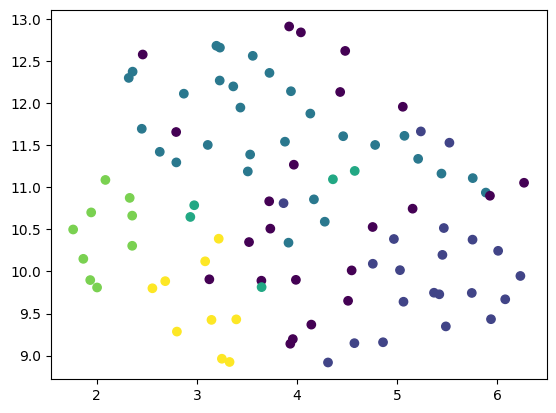

cluster
 1    29
-1    23
 0    21
 4     9
 3     9
 2     5
Name: count, dtype: int64


In [ ]:
import hdbscan
import umap
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import pandas as pd
import re


with open("papers_with_alzheimer_flag_ollama_1_filtered.json","r", encoding='utf-8') as file:
    data = json.load(file)

texts = [f"{art.get('title', '')} {art.get('summary', '')}" for art in data]

texts = []
for art in tqdm(data, desc="Préparation des textes"):
    link = art.get("link", "")

    # retrouver l'ID arXiv
    arxiv_id = link.split("/")[-1] if link else None
    pdf_path = os.path.join(pdf_dir, f"{arxiv_id}.pdf") if arxiv_id else None

    pdf_text = ""
    if pdf_path and os.path.exists(pdf_path):
        pdf_text = extract_text_from_pdf(pdf_path, max_pages=5)  # limite 5 pages pour rapidité
    else:
        pdf_text = ""

    full_text = f"{pdf_text}"
    texts.append(full_text)
    
def clean_text(text: str) -> str:
    text = text.lower()

    # enlever caractères bizarres PDF
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"-\n", "", text)      # mots coupés fin de ligne
    text = re.sub(r"\n", " ", text)

    # enlever URLs, emails
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)

    # garder lettres et chiffres
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    return text.strip()


# Model used
model = SentenceTransformer("allenai/scibert_scivocab_uncased")

# Embeddings
embeddings = model.encode(
    texts_cleaned,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Umap to compact the data
umap_reducer = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)
embeddings_umap = umap_reducer.fit_transform(embeddings)

# Clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
    metric="euclidean"
)

# Prediction clustering
labels = clusterer.fit_predict(embeddings_umap)
pd.Series(labels).value_counts()


# Visualisation
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(embeddings)
plt.scatter(umap_2d[:,0], umap_2d[:,1], c=labels)
plt.show()

df = pd.DataFrame({
    "text": texts,
    "cluster": labels
})

print(df["cluster"].value_counts())


In [30]:
%pip install keybert


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 KB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [31]:
from keybert import KeyBERT

kw_model = KeyBERT(model)

cluster_keywords = {}

for cluster_id in sorted(df_valid["cluster"].unique()):
    texts_cluster = df_valid[df_valid["cluster"] == cluster_id]["text"].tolist()
    joined_text = " ".join(texts_cluster)[:20000]  # limiter longueur

    keywords = kw_model.extract_keywords(
        joined_text,
        keyphrase_ngram_range=(1, 2),
        stop_words="english",
        top_n=5
    )

    cluster_keywords[cluster_id] = [kw for kw, score in keywords]




In [32]:
cluster_names = {
    cid: " / ".join(words[:3])
    for cid, words in cluster_keywords.items()
}

df["cluster_name"] = df["cluster"].map(cluster_names).fillna("Noise / Mixed")


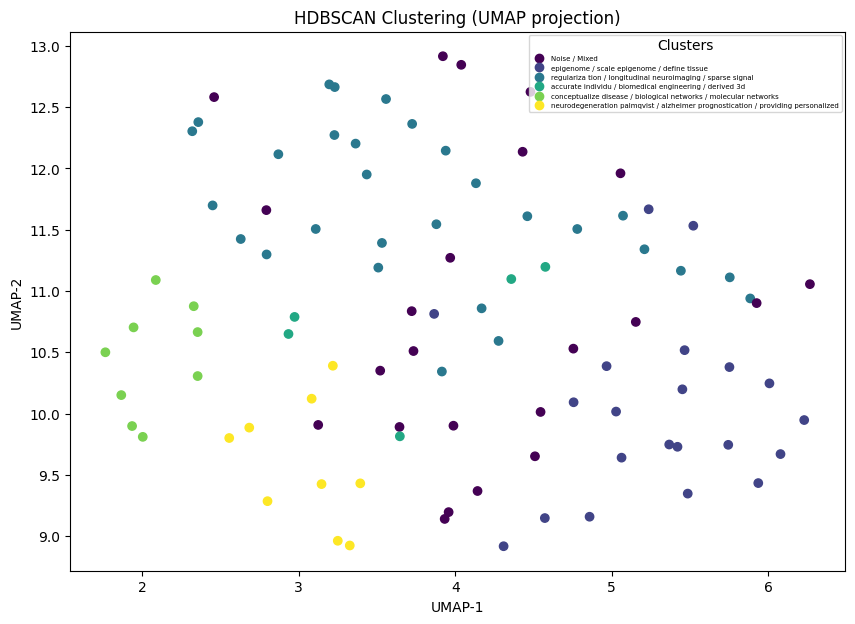

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=labels
)

# Créer une légende cluster → nom
handles, legend_labels = sc.legend_elements(prop="colors")
unique_clusters = sorted(set(labels))

legend_texts = [
    cluster_names.get(c, "Noise / Mixed") if c != -1 else "Noise / Mixed"
    for c in unique_clusters
]

plt.legend(
    handles,
    legend_texts,
    title="Clusters",
    loc="best",
    fontsize=5
)

plt.title("HDBSCAN Clustering (UMAP projection)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


In [37]:
def get_article_id(art, idx):
    return art.get("id") or art.get("link") or f"idx_{idx}"

clusters_json = {"clusters": []}

for cluster_id in sorted(df["cluster"].unique()):
    cluster_df = df[df["cluster"] == cluster_id]

    article_ids = []
    for idx in cluster_df.index:
        art = data[idx]
        article_ids.append(get_article_id(art, idx))

    clusters_json["clusters"].append({
        "cluster_id": int(cluster_id),
        "cluster_name": cluster_df["cluster_name"].iloc[0],
        "size": len(article_ids),
        "article_ids": article_ids
    })

import json

with open("alzheimer_clusters.json", "w", encoding="utf-8") as f:
    json.dump(clusters_json, f, indent=2, ensure_ascii=False)


## Clustering par modalité

Une seconde manière serait de déceler les modalités des articles et de les regrouper par ces modalités.

In [ ]:
def classify_modality(paper, modality_list):
    prompt = f"""
Available modality_ids:
{chr(10).join('- ' + m for m in modality_list)}

Return ONLY JSON.

Title:
{paper['title']}

Abstract:
{paper['summary']}
"""
    return json.loads(ask_ollama(prompt))

with open("papers_with_alzheimer_flag_ollama_1_filtered.json","r", encoding='utf-8') as file:
    data = json.load(file)

texts = [f"{art.get('title', '')} {art.get('summary', '')}" for art in data]

texts = []
for art in tqdm(data, desc="Préparation des textes"):
    link = art.get("link", "")

    # retrouver l'ID arXiv
    arxiv_id = link.split("/")[-1] if link else None
    pdf_path = os.path.join(pdf_dir, f"{arxiv_id}.pdf") if arxiv_id else None

    pdf_text = ""
    if pdf_path and os.path.exists(pdf_path):
        pdf_text = extract_text_from_pdf(pdf_path, max_pages=5)
    else:
        pdf_text = ""

    full_text = f"{pdf_text}"
    texts.append(full_text)


def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode(),
        capture_output=True
    )
    return result.stdout.decode().strip()

def build_cluster_modalite_prompt(paper, bib_id):
    return f"""
You have to find the modalities in the following 

Reference: [#{bib_id}]

Title:
{paper['title']}

Abstract:
{paper['summary']}
"""

prompt = build_cluster_modalite_prompt(
)

print(len(prompt),prompt,sep="\n\n")

cluster_synthesis = ask_ollama(prompt)





def get_article_id(art, idx):
    return art.get("id") or art.get("link") or f"idx_{idx}"

clusters_json = {"clusters": []}

for cluster_id in sorted(df["cluster"].unique()):
    cluster_df = df[df["cluster"] == cluster_id]

    article_ids = []
    for idx in cluster_df.index:
        art = data[idx]
        article_ids.append(get_article_id(art, idx))

    clusters_json["clusters"].append({
        "cluster_id": int(cluster_id),
        "cluster_name": cluster_df["cluster_name"].iloc[0],
        "size": len(article_ids),
        "article_ids": article_ids
    })

import json

with open("alzheimer_clusters.json", "w", encoding="utf-8") as f:
    json.dump(clusters_json, f, indent=2, ensure_ascii=False)


In [ ]:
import os
import json
import subprocess
from collections import defaultdict
from tqdm import tqdm
import re

# =========================
# CONFIGURATION
# =========================

MODEL_NAME = "gemma3:4b"
INPUT_JSON = "papers_with_alzheimer_flag_ollama_1_filtered.json"
OUTPUT_JSON = "alzheimer_llm_modalities_clustersV3.json"

# Définition déterministique des modalités Alzheimer
MODALITIES = {
    "NEUROIMAGING_BIOMARKERS": (
        "Brain imaging studies using MRI, PET, fMRI, DTI or CT "
        "to measure Alzheimer's disease related changes."
    ),
    "AMYLOID_BETA_PATHOLOGY": (
        "Studies focused on amyloid-beta plaques, aggregation, "
        "clearance, or amyloid biomarkers."
    ),
    "TAU_PATHOLOGY": (
        "Studies focused on tau protein, neurofibrillary tangles, "
        "tau phosphorylation or propagation."
    ),
    "NEUROINFLAMMATION_AND_GLIAL_RESPONSE": (
        "Research involving microglia, astrocytes, immune response "
        "or neuroinflammation in Alzheimer's disease."
    ),
    "GENETIC_RISK_FACTORS": (
        "Studies on genetic variants such as APOE, GWAS, heritability "
        "and genetic susceptibility to Alzheimer's disease."
    ),
    "CLINICAL_DIAGNOSIS_AND_PROGRESSION": (
        "Clinical studies on diagnosis, disease stages, progression, "
        "cognitive tests and patient cohorts."
    ),
    "THERAPEUTIC_INTERVENTIONS": (
        "Research on drug treatments, therapies, clinical trials "
        "or therapeutic targets for Alzheimer's disease."
    ),
    "CELLULAR_MODELS": (
        "Studies using animal models, cell cultures, organoids "
        "or experimental Alzheimer's disease models."
    ),
    "MOLECULAR_PATHWAYS": (
        "Studies on molecular, biochemical or cellular mechanisms "
        "underlying Alzheimer's disease."
    ),
    "NEW_MODALITY": (
        "Use only if none of the above clearly apply."
    )
}


# =========================
# UTILITAIRES LLM
# =========================

def ask_ollama(prompt, model=MODEL_NAME):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode("utf-8"),
        capture_output=True
    )
    return result.stdout.decode("utf-8").strip()


def build_modality_prompt(paper, modalities):
    modalities_block = "\n".join(
        f"{k}: {v}" for k, v in modalities.items()
    )

    return f"""
You are classifying Alzheimer's disease research articles.

You MUST choose EXACTLY ONE modality_id.
You MUST choose the CLOSEST modality even if the match is imperfect.
Use NEW_MODALITY ONLY if the article is clearly unrelated to all descriptions.

Available modalities:
{modalities_block}

Return ONLY valid JSON:
{{
  "modality_id": "ONE_MODALITY_ID"
}}

Title:
{paper.get("title", "")}

Abstract:
{paper.get("summary", "")}
"""


def parse_llm_json(output):
    """
    Nettoie les fences ```json ``` et parse le JSON.
    """
    try:
        # Supprimer les ```json et ```
        cleaned = re.sub(r"```json|```", "", output).strip()
        return json.loads(cleaned)
    except Exception as e:
        return {"modality_id": "NEW_MODALITY"}


# =========================
# IDENTIFIANT ARTICLE
# =========================

def get_article_id(art, idx):
    return (
        art.get("id")
        or art.get("bib_id")
        or art.get("link")
        or f"idx_{idx}"
    )


# =========================
# PIPELINE PRINCIPAL
# =========================

def main():
    with open(INPUT_JSON, "r", encoding="utf-8") as f:
        data = json.load(f)

    clusters = defaultdict(list)

    for idx, paper in enumerate(tqdm(data, desc="LLM modality classification")):
        prompt = build_modality_prompt(paper, MODALITIES)
        llm_output = ask_ollama(prompt)
        result = parse_llm_json(llm_output)

        modality = result.get("modality_id", "NEW_MODALITY")

        if modality not in MODALITIES or modality == "NEW_MODALITY":
            modality = "MOLECULAR_PATHWAYS"

        article_id = get_article_id(paper, idx)
        clusters[modality].append(article_id)

    # =========================
    # EXPORT JSON
    # =========================

    output = {
        "method": "LLM_deterministic_modality_clustering",
        "model": MODEL_NAME,
        "modalities": []
    }

    for modality_id, article_ids in clusters.items():
        output["modalities"].append({
            "modality_id": modality_id,
            "size": len(article_ids),
            "article_ids": article_ids
        })

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)


# =========================
# EXECUTION
# =========================

if __name__ == "__main__":
    main()


LLM modality classification:   1%|          | 1/96 [00:00<01:15,  1.27it/s]

RAW LLM OUTPUT:
```json
{
  "modality_id": "TRANSFORMER_MODEL"
}
```


LLM modality classification:   2%|▏         | 2/96 [00:01<01:00,  1.56it/s]

RAW LLM OUTPUT:
```json
{
  "modality_id": "TRANSFORMER_MODEL"
}
```


LLM modality classification:   3%|▎         | 3/96 [00:01<00:56,  1.66it/s]

...

LLM modality classification:   4%|▍         | 4/96 [00:02<00:55,  1.66it/s]

RAW LLM OUTPUT:
```json
{
  "modality_id": "NEUROIMAGING_BIOMARKERS"
}
```


LLM modality classification:   5%|▌         | 5/96 [00:03<00:55,  1.64it/s]

RAW LLM OUTPUT:
```json
{
  "modality_id": "NEUROIMAGING_BIOMARKERS"
}
```


LLM modality classification: 100%|██████████| 96/96 [00:57<00:00,  1.67it/s]


On peut cependant s'interroger sur le fait d'utiliser qu'un seul modèle pour classer les articles. En effet, il suffit de relancer la requête pour obtenir des résultats différents pour certains articles. <br><br>
Mettons donc en place un système de vote par l'utilisation de plusieurs modèles.

In [ ]:
import json
import subprocess
import re
from collections import defaultdict, Counter
from tqdm import tqdm

# =========================
# CONFIGURATION
# =========================

MODELS = [
    "gemma3:4b",
    "llama3.1:latest",
    "mistral:7b-instruct",
    "qwen2.5:7b-instruct",
    "phi3:mini",
]

INPUT_JSON = "papers_with_alzheimer_flag_ollama_1_filtered.json"
OUTPUT_JSON = "alzheimer_llm_modalities_clusters_vote_New_modality.json"

# Ordre déterministe pour casser les égalités
MODALITY_PRIORITY = [
    "NEUROIMAGING_BIOMARKERS",
    "AMYLOID_BETA_PATHOLOGY",
    "TAU_PATHOLOGY",
    "NEUROINFLAMMATION_AND_GLIAL_RESPONSE",
    "GENETIC_RISK_FACTORS",
    "CLINICAL_DIAGNOSIS_AND_PROGRESSION",
    "THERAPEUTIC_INTERVENTIONS",
    "CELLULAR_MODELS",
    "MOLECULAR_PATHWAYS",
    "NEW_MODALITY",
]

# =========================
# MODALITÉS
# =========================

MODALITIES = {
    "NEUROIMAGING_BIOMARKERS": (
        "Brain imaging studies using MRI, PET, fMRI, DTI or CT "
        "to measure Alzheimer's disease related changes."
    ),
    "AMYLOID_BETA_PATHOLOGY": (
        "Studies focused on amyloid-beta plaques, aggregation, "
        "clearance, or amyloid biomarkers."
    ),
    "TAU_PATHOLOGY": (
        "Studies focused on tau protein, neurofibrillary tangles, "
        "tau phosphorylation or propagation."
    ),
    "NEUROINFLAMMATION_AND_GLIAL_RESPONSE": (
        "Research involving microglia, astrocytes, immune response "
        "or neuroinflammation in Alzheimer's disease."
    ),
    "GENETIC_RISK_FACTORS": (
        "Studies on genetic variants such as APOE, GWAS, heritability "
        "and genetic susceptibility to Alzheimer's disease."
    ),
    "CLINICAL_DIAGNOSIS_AND_PROGRESSION": (
        "Clinical studies on diagnosis, disease stages, progression, "
        "cognitive tests and patient cohorts."
    ),
    "THERAPEUTIC_INTERVENTIONS": (
        "Research on drug treatments, therapies, clinical trials "
        "or therapeutic targets for Alzheimer's disease."
    ),
    "CELLULAR_MODELS": (
        "Studies using animal models, cell cultures, organoids "
        "or experimental Alzheimer's disease models."
    ),
    "MOLECULAR_PATHWAYS": (
        "Studies on molecular, biochemical or cellular mechanisms "
        "underlying Alzheimer's disease."
    ),
    "NEW_MODALITY": (
        "Use only if none of the above clearly apply."
    )
}

# =========================
# LLM UTILITIES
# =========================

def ask_ollama(prompt, model):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode("utf-8"),
        capture_output=True
    )
    return result.stdout.decode("utf-8").strip()


def build_modality_prompt(paper):
    modalities_block = "\n".join(
        f"{k}: {v}" for k, v in MODALITIES.items()
    )

    return f"""
You are classifying Alzheimer's disease research articles.

You MUST choose EXACTLY ONE modality_id.
You MUST choose the CLOSEST modality even if the match is imperfect.
Use NEW_MODALITY ONLY if the article is clearly unrelated.

Available modalities:
{modalities_block}

Return ONLY valid JSON:
{{
  "modality_id": "ONE_MODALITY_ID"
}}

Title:
{paper.get("title", "")}

Abstract:
{paper.get("summary", "")}
"""


def parse_llm_json(output):
    try:
        cleaned = re.sub(r"```json|```", "", output).strip()
        parsed = json.loads(cleaned)
        modality = parsed.get("modality_id", "NEW_MODALITY")

        if modality not in MODALITIES:
            return "NEW_MODALITY"

        return modality
    except Exception:
        return "NEW_MODALITY"



# =========================
# VOTE LOGIC
# =========================
def consensus_vote(predictions, min_agreement=3):
    """
    Returns:
      - final_modality
      - agreement_count
      - confident (bool)
    """
    counts = Counter(predictions)
    modality, votes = counts.most_common(1)[0]

    if votes >= min_agreement:
        return modality, votes, True

    return "NEW_MODALITY", votes, False


# =========================
# ARTICLE ID
# =========================

def get_article_id(art, idx):
    return (
        art.get("id")
        or art.get("bib_id")
        or art.get("link")
        or f"idx_{idx}"
    )


# =========================
# MAIN PIPELINE
# =========================

def main():
    with open(INPUT_JSON, "r", encoding="utf-8") as f:
        data = json.load(f)

    clusters = defaultdict(list)
    audit = []

    for idx, paper in enumerate(tqdm(data, desc="LLM multi-model voting")):
        predictions = {}

        prompt = build_modality_prompt(paper)

        for model in MODELS:
            raw = ask_ollama(prompt, model)
            modality = parse_llm_json(raw)
            predictions[model] = modality

        final_modality, agreement, confident = consensus_vote(
            list(predictions.values()),
            min_agreement=(len(MODELS)//2)+1
        )

        article_id = get_article_id(paper, idx)

        clusters[final_modality].append(article_id)

        audit.append({
            "article_id": article_id,
            "final_modality": final_modality,
            "agreement": f"{agreement}/{len(MODELS)}",
            "confident": confident,
            "votes": predictions
        })

    # =========================
    # EXPORT
    # =========================

    output = {
        "method": "LLM_multi_model_majority_vote",
        "models": MODELS,
        "modalities": [],
        "audit": audit
    }

    for modality_id, article_ids in clusters.items():
        output["modalities"].append({
            "modality_id": modality_id,
            "size": len(article_ids),
            "article_ids": article_ids
        })

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)


if __name__ == "__main__":
    main()


LLM multi-model voting: 100%|██████████| 96/96 [1:36:37<00:00, 60.39s/it]


## Test autre type clustering

In [9]:
import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.metrics import ConfusionMatrix
from nltk.stem.snowball import SnowballStemmer
from nltk import word_tokenize, WordNetLemmatizer

def preprocess(sentence):
    """
    Tokenizes, lowers, and stems
    """
    stemmer = SnowballStemmer('english')
    lemmatizer = WordNetLemmatizer()
    # Lower the sentence
    lower_mail = sentence.lower()
    # Tokenize it
    tokenized_mail = word_tokenize(lower_mail)
    # Get POS for each word
    pos_tagged_mail = nltk.pos_tag(tokenized_mail)
    # Lemmatize
    lemmatized_mail = [lemmatizer.lemmatize(word[0],get_wordnet_pos(word[1])) for word in pos_tagged_mail]
    # Stem
    stemmed_email = [stemmer.stem(word) for word in lemmatized_mail]
    return stemmed_email

for i in texts:
    preprocess(i)

print(texts)

NameError: name 'get_wordnet_pos' is not defined

In [ ]:

# === 4. Embeddings ===
model = SentenceTransformer("allenai/scibert_scivocab_uncased")
embeddings = model.encode(texts, show_progress_bar=True)

# === 5. Clustering ===
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(embeddings)

# === 6. Évaluation + aperçu ===
print("Silhouette:", silhouette_score(embeddings, labels))

df = pd.DataFrame({
    "title": [a["title"] for a in data],
    "cluster": labels
})

print(df.groupby("cluster").size())

for c in sorted(df["cluster"].unique()):
    print(f"\n--- Cluster {c} ---")
    print("\n".join(df[df["cluster"] == c]["title"].head(5)))


k=2 -> silhouette=0.134
k=3 -> silhouette=0.087
k=4 -> silhouette=0.045
k=5 -> silhouette=0.025
k=6 -> silhouette=0.015
k=7 -> silhouette=0.012
k=8 -> silhouette=0.024
k=9 -> silhouette=0.021
k=10 -> silhouette=0.023
k=11 -> silhouette=0.033
k=12 -> silhouette=0.033
k=13 -> silhouette=0.036
k=14 -> silhouette=0.035
k=15 -> silhouette=0.037
k=16 -> silhouette=0.038
k=17 -> silhouette=0.037
k=18 -> silhouette=0.031
k=19 -> silhouette=0.030
k=20 -> silhouette=0.028
k=21 -> silhouette=0.034
k=22 -> silhouette=0.030
k=23 -> silhouette=0.032
k=24 -> silhouette=0.028
k=25 -> silhouette=0.030
k=26 -> silhouette=0.033
k=27 -> silhouette=0.035
k=28 -> silhouette=0.031
k=29 -> silhouette=0.029
k=30 -> silhouette=0.027
k=31 -> silhouette=0.029
k=32 -> silhouette=0.031
k=33 -> silhouette=0.031
k=34 -> silhouette=0.031
k=35 -> silhouette=0.030
k=36 -> silhouette=0.030
k=37 -> silhouette=0.032
k=38 -> silhouette=0.030
k=39 -> silhouette=0.017
k=40 -> silhouette=0.017
k=41 -> silhouette=0.016
k=42 -> 

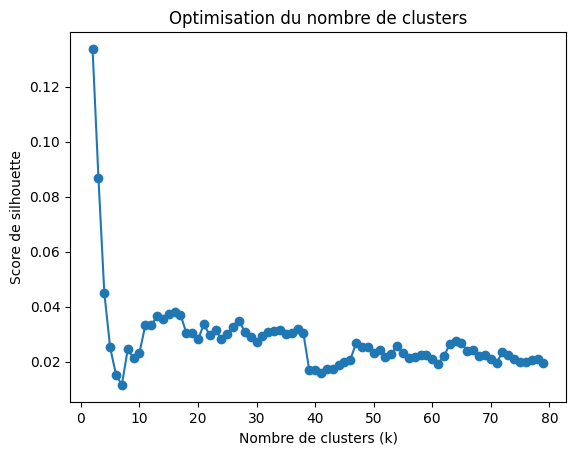

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

scores = []

# Tester différents nombres de clusters
for k in range(2, 80): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    scores.append((k, score))
    print(f"k={k} -> silhouette={score:.3f}")

# Trouver le meilleur k
best_k, best_score = max(scores, key=lambda x: x[1])
print(f"\n✅ Meilleur k = {best_k} (score={best_score:.3f})")

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(embeddings)

import matplotlib.pyplot as plt

ks, sils = zip(*scores)
plt.plot(ks, sils, marker='o')
plt.xlabel("Nombre de clusters (k)")²
plt.ylabel("Score de silhouette")
plt.title("Optimisation du nombre de clusters")
plt.show()


In [35]:
import hdbscan
import pandas as pd
from sentence_transformers import SentenceTransformer

# embeddings déjà calculés
# embeddings = model.encode(texts, show_progress_bar=True)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,        # taille min d’un groupe
    metric='euclidean',        # distance
    cluster_selection_method='eom'
).fit(embeddings)

labels = clusterer.labels_
df = pd.DataFrame({
    "title": [a["title"] for a in data],
    "cluster": labels
})

print(df["cluster"].value_counts())


/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


cluster
-1    86
Name: count, dtype: int64


In [ ]:
import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.metrics import ConfusionMatrix
from nltk.stem.snowball import SnowballStemmer
from nltk import word_tokenize, WordNetLemmatizer

def preprocess(sentence):
    """
    Tokenizes, lowers, and stems
    """
    stemmer = SnowballStemmer('english')
    lemmatizer = WordNetLemmatizer()
    # Lower the sentence
    lower_mail = sentence.lower()
    # Tokenize it
    tokenized_mail = word_tokenize(lower_mail)
    # Get POS for each word
    pos_tagged_mail = nltk.pos_tag(tokenized_mail)
    # Lemmatize
    lemmatized_mail = [lemmatizer.lemmatize(word[0],get_wordnet_pos(word[1])) for word in pos_tagged_mail]
    # Stem
    stemmed_email = [stemmer.stem(word) for word in lemmatized_mail]
    return stemmed_email

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("allenai/scibert_scivocab_uncased")
embeddings = model.encode(texts, show_progress_bar=True)



topic_model = BERTopic(embedding_model=model)
topics, probs = topic_model.fit_transform(texts)

# Aperçu des thèmes trouvés
topic_model.get_topic_info().head()

# Top mots-clés par thème
for i in range(5):
    print(f"\n--- Thème {i} ---")
    print(topic_model.get_topic(i))


No sentence-transformers model found with name allenai/scibert_scivocab_uncased. Creating a new one with mean pooling.
Exception ignored in: <function tqdm.__del__ at 0x7f8699dd8820>
Traceback (most recent call last):
  File "/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/mnt/c/Users/benja/Desktop/cours_ESME/cours/INGE/INGE_3/Master_projet_innovation_recherche/core/.venv/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


--- Thème 0 ---
[('the', np.float64(0.09480875908033812)), ('and', np.float64(0.0757193899161094)), ('of', np.float64(0.060680776847704905)), ('to', np.float64(0.056074119562768726)), ('in', np.float64(0.044354815718498794)), ('for', np.float64(0.03819987667372932)), ('with', np.float64(0.031013379016426985)), ('is', np.float64(0.03039538388005212)), ('we', np.float64(0.029281305484368584)), ('as', np.float64(0.026796405032975385))]

--- Thème 1 ---
[('the', np.float64(0.09652375221169857)), ('and', np.float64(0.07604038027435521)), ('of', np.float64(0.073882878764699)), ('to', np.float64(0.055958135822724686)), ('in', np.float64(0.05195895211773592)), ('for', np.float64(0.04246144465677013)), ('is', np.float64(0.031166594568009166)), ('with', np.float64(0.03038085233281182)), ('we', np.float64(0.02599388872972192)), ('this', np.float64(0.025054685613585554))]

--- Thème 2 ---
False

--- Thème 3 ---
False

--- Thème 4 ---
False


## Troisième étape : Analyse et génération du rapport 

### Système 1 prompt

Nous allons tout d'abord remettre en ordre les citations.

In [1]:
import json

def paper_to_bibtex(paper):
    authors = " and ".join(paper["authors"])
    year = paper.get("year")
    if year is None and paper.get("published"):
        year = paper["published"][:4]

    arxiv_id = paper["arxiv_id"]
    primary_class = paper["primary_category"]

    key_author = paper["authors"][0].split()[-1].lower()
    bib_key = f"{key_author}{year}{paper['title'].split()[0].lower()}"

    bibtex = f"""@misc{{{bib_key},
  title={{ {paper['title']} }},
  author={{ {authors} }},
  year={{ {year} }},
  eprint={{ {arxiv_id} }},
  archivePrefix={{arXiv}},
  primaryClass={{ {primary_class} }},
  url={{ https://arxiv.org/abs/{arxiv_id} }}
}}
"""
    return bibtex

with open("papers_with_alzheimer_flag_ollama_1_filtered.json") as f:
    papers = json.load(f)

bib_entries = []
for p in papers:
    if p["is_about_alzheimer"]:
        bib_entries.append(paper_to_bibtex(p))

with open("alzheimer_state_of_the_art.bib", "w") as f:
    f.write("\n".join(bib_entries))


Occupons-nous maintenant de résumer chaque article pour normaliser le tout.

In [14]:
import subprocess
import json
from tqdm import tqdm

def build_article_prompt(paper, bib_id):
    return f"""
You are a biomedical research expert.

Rewrite the following content as a neutral, continuous scientific description of methods and findings.
Remove all meta-text, bullets, and labels. Output of 5-7 sentences.

Reference: [#{bib_id}]

Title:
{paper['title']}

Abstract:
{paper['summary']}
"""

def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode(),
        capture_output=True
    )
    return result.stdout.decode().strip()


def summarize_articles(papers):
    summaries = []

    for bib_id, paper in enumerate(tqdm(papers), 1):
        prompt = build_article_prompt(paper, bib_id)
        summary = ask_ollama(prompt)

        summaries.append({
            "bib_id": bib_id,
            "arxiv_id": paper["arxiv_id"],
            "title": paper["title"],
            "summary_structured": summary
        })

    return summaries


In [29]:

with open("papers_with_alzheimer_flag_ollama_1_filtered.json", "r") as f:
    papers = json.load(f)
    
summaries = summarize_articles(papers)

with open("cluster_2_article_summaries.json", "w") as f:
    json.dump(summaries, f, indent=2)


100%|██████████| 96/96 [04:47<00:00,  3.00s/it]


Reprennons tous les articles résumés pour n'en avoir plus qu'un.

In [11]:
def build_cluster_prompt(cluster_name, article_summaries):
    joined = "\n\n".join(
        f"[#{a['bib_id']}]\n{a['summary_structured']}"
        for a in article_summaries
    )

    return f"""

    You are writing a scientific state-of-the-art section
    for a research article on Alzheimer's disease.

    The text you must produce is NOT a review, NOT feedback,
    NOT an evaluation, and NOT comments on the summaries.

    Your task is to WRITE a SYNTHETIC, COHERENT ACADEMIC TEXT
    that integrates the scientific contributions of the articles below.

    The text below is NOT a set of summaries.
    It is a collection of factual scientific statements extracted from multiple studies.
    You must treat it as raw scientific material.

    Instructions:
    - Write in continuous prose (paragraphs), not bullet points.
    - Do NOT address the reader.
    - Do NOT comment on the quality of the studies.
    - Do NOT give suggestions or opinions.
    - Do NOT mention "these summaries" or "the articles above".
    - Do NOT include meta-commentary.

    Scientific goals:
    - Identify and describe the main research directions of this cluster.
    - Explain how different approaches complement or differ from each other.
    - Emphasize methodological advances and scientific insights.
    - Maintain a neutral, factual, academic tone.

    Citations:
    - Cite studies using their reference number [#].
    - Only cite articles that support the stated claims.
    - Do NOT invent results.

    Output format constraint (MANDATORY):
    - The output MUST consist of 2 to 4 paragraphs.
    - Each paragraph MUST be at least 4 sentences long.
    - The output MUST NOT contain:
    "-", "•", "*", numbered lists, headings, or bold text.
    - If any bullet points or lists are used, the output is INVALID.
    - Start directly with the first paragraph. Do not add introductions.


    Title of the section:
    "{cluster_name}"

    Articles:
    {joined}

    """
def normalize_arxiv_id(url):
    raw = url.split("/")[-1]
    return re.sub(r"v\d+$", "", raw)

import json
import re


TARGET_CLUSTER_ID = 3

with open("alzheimer_clusters.json", "r") as f:
    clusters_data = json.load(f)

cluster = next(
    c for c in clusters_data["clusters"]
    if c["cluster_id"] == TARGET_CLUSTER_ID
)
cluster_name = cluster["cluster_name"]


In [12]:
print(cluster_name,len(cluster),cluster,sep="\n")

conceptualize disease / biological networks / molecular networks
4
{'cluster_id': 3, 'cluster_name': 'conceptualize disease / biological networks / molecular networks', 'size': 9, 'article_ids': ['https://arxiv.org/abs/2511.18238v2', 'https://arxiv.org/abs/2512.10981v1', 'https://arxiv.org/abs/2512.04937v1', 'https://arxiv.org/abs/2511.01732v2', 'https://arxiv.org/abs/2512.05993v1', 'https://arxiv.org/abs/2511.18320v1', 'https://arxiv.org/abs/2511.10369v1', 'https://arxiv.org/abs/2511.08847v1', 'https://arxiv.org/abs/2504.07913v2']}


In [13]:

# Extraire les arXiv IDs du cluster
cluster_arxiv_ids = {
    normalize_arxiv_id(url)
    for url in cluster["article_ids"]
}

with open(f"cluster_0_article_summaries.json", "r") as f:
    all_summaries = json.load(f)

article_summaries = sorted(
    [
        s for s in all_summaries
        if normalize_arxiv_id(s["arxiv_id"]) in cluster_arxiv_ids
    ],
    key=lambda x: x["bib_id"]
)
assert len(article_summaries) == len(cluster_arxiv_ids), (
    f"Mismatch: {len(article_summaries)} summaries "
    f"for {len(cluster_arxiv_ids)} cluster articles"
)


print(cluster_arxiv_ids,len(cluster_arxiv_ids),sep="\n")
print(article_summaries,len(article_summaries),sep="\n")

{'2511.18238', '2511.08847', '2511.18320', '2512.04937', '2511.01732', '2512.10981', '2511.10369', '2504.07913', '2512.05993'}
9
[{'bib_id': 29, 'arxiv_id': '2511.18238', 'title': 'Detecting Discontinuities in the Topology of Alzheimers gene Co-expression', 'summary_structured': 'Comparative topological analysis was employed to investigate disruptions in gene co-expression networks associated with Alzheimer’s disease. The methodology utilized topological data analysis (TDA) and the Mapper algorithm to identify discontinuities within the topology of gene-gene relationships, contrasting gene expression patterns between healthy and Alzheimer’s disease brain tissue across three distinct brain regions. A variability-based node scoring approach was then utilized to pinpoint localized disruptions, termed discontinuity hotspots, within the co-expression space. Subsequent Gene Ontology Biological Process enrichment analysis was performed on these identified hotspots to assess their biological s

In [14]:

# Build prompt using articles from the JSON file
prompt = build_cluster_prompt(
    cluster_name=cluster_name,
    article_summaries=article_summaries
)

print(len(prompt),prompt,sep="\n\n")

cluster_synthesis = ask_ollama(prompt)

print(cluster_synthesis)

with open(f"Result_state_of_the_art_1.txt", "w") as f:
    f.write(cluster_synthesis)



16037



    You are writing a scientific state-of-the-art section
    for a research article on Alzheimer's disease.

    The text you must produce is NOT a review, NOT feedback,
    NOT an evaluation, and NOT comments on the summaries.

    Your task is to WRITE a SYNTHETIC, COHERENT ACADEMIC TEXT
    that integrates the scientific contributions of the articles below.

    The text below is NOT a set of summaries.
    It is a collection of factual scientific statements extracted from multiple studies.
    You must treat it as raw scientific material.

    Instructions:
    - Write in continuous prose (paragraphs), not bullet points.
    - Do NOT address the reader.
    - Do NOT comment on the quality of the studies.
    - Do NOT give suggestions or opinions.
    - Do NOT mention "these summaries" or "the articles above".
    - Do NOT include meta-commentary.

    Scientific goals:
    - Identify and describe the main research directions of this cluster.
    - Explain how different ap

NameError: name 'subprocess' is not defined

In [27]:
print(len("The research investigated the development of stochastic Siamese Masked Autoencoding (MAE) pretraining for longitudinal medical image analysis. The study focused on creating temporally aware image representations, recognizing the importance of capturing disease progression within 3D volumes of longitudinal datasets. A novel framework, termed STAMP (Stochastic Temporal Autoencoder with Masked Pretraining), was developed. STAMP utilized a Siamese architecture incorporating a stochastic process to encode temporal information. Specifically, the model was conditioned on the time difference between two input volumes. Unlike previous deterministic Siamese approaches, STAMP incorporated stochasticity into the learning process, reframing the masked autoencoding reconstruction loss as a conditional variational inference objective. The framework was evaluated on two optical coherence tomography (OCT) datasets and one magnetic resonance imaging (MRI) dataset, each containing multiple visits from the same patient. The results demonstrated that STAMP pretrained Vision Transformer (ViT) models achieved superior performance compared to existing temporal MAE methods and foundational models across various late-stage Age-Related Macular Degeneration and Alzheimer\u2019s Disease progression prediction tasks. These tasks demanded that models learn the underlying non-deterministic temporal dynamics characteristic of these diseases."))

1427


In [15]:
import json

# Load article summaries for the cluster
with open("cluster_2_article_summaries.json", "r") as f:
    article_summaries = json.load(f)

# Build prompt using articles from the JSON file
prompt = build_cluster_prompt(
    cluster_name="epigenome / scale epigenome / define tissue",
    article_summaries=article_summaries
)

# Generate state-of-the-art synthesis
cluster_synthesis = ask_ollama(prompt)
print(cluster_synthesis)
# Save result
with open("cluster_1_state_of_the_art.txt", "w") as f:
    f.write(cluster_synthesis)

NameError: name 'subprocess' is not defined

In [5]:
import json

TARGET_CLUSTER_ID = 0

with open("alzheimer_clusters.json", "r") as f:
    clusters_data = json.load(f)


cluster = next(
    c for c in clusters_data["clusters"]
    if c["cluster_id"] == TARGET_CLUSTER_ID
)
print(cluster)

cluster_name = cluster["cluster_name"]

{'cluster_id': 0, 'cluster_name': 'epigenome / scale epigenome / define tissue', 'size': 21, 'article_ids': ['https://arxiv.org/abs/2601.00143v1', 'https://arxiv.org/abs/2512.23441v1', 'https://arxiv.org/abs/2512.23093v1', 'https://arxiv.org/abs/2512.20948v1', 'https://arxiv.org/abs/2512.18986v1', 'https://arxiv.org/abs/2508.20717v2', 'https://arxiv.org/abs/2512.16184v1', 'https://arxiv.org/abs/2512.15947v1', 'https://arxiv.org/abs/2412.01865v4', 'https://arxiv.org/abs/2507.01794v2', 'https://arxiv.org/abs/2512.06134v1', 'https://arxiv.org/abs/2512.05814v1', 'https://arxiv.org/abs/2511.20704v1', 'https://arxiv.org/abs/2511.15188v2', 'https://arxiv.org/abs/2511.14601v1', 'https://arxiv.org/abs/2511.05810v2', 'https://arxiv.org/abs/2511.08132v2', 'https://arxiv.org/abs/2508.01292v2', 'https://arxiv.org/abs/2508.10027v3', 'https://arxiv.org/abs/2511.05841v1', 'https://arxiv.org/abs/2511.02735v1']}


In [10]:


# Extraire les arXiv IDs du cluster
cluster_arxiv_ids = {
    url.split("/")[-1].replace("v1", "").replace("v2", "").replace("v3", "").replace("v4", "")
    for url in cluster["article_ids"]
}

print(cluster_arxiv_ids)

{'2511.05810', '2511.20704', '2512.23093', '2511.15188', '2412.01865', '2511.05841', '2512.05814', '2507.01794', '2508.20717', '2508.01292', '2512.15947', '2601.00143', '2512.06134', '2511.14601', '2508.10027', '2512.20948', '2512.23441', '2512.16184', '2511.08132', '2512.18986', '2511.02735'}


In [6]:

with open("cluster_2_article_summaries.json", "r") as f:
    all_summaries = json.load(f)

article_summaries = [
    s for s in all_summaries
    if s["arxiv_id"] in cluster_arxiv_ids
]
print(article_summaries, len(article_summaries),sep="\n")

[{'bib_id': 14, 'arxiv_id': '2505.11622', 'title': 'The Stochastic Occupation Kernel (SOCK) Method for Learning Stochastic Differential Equations', 'summary_structured': "The stochastic occupation kernel (SOCK) method employs a kernel-based approach to learn multivariate stochastic differential equations. The technique utilizes occupation kernels, integral functionals within a reproducing kernel Hilbert space, to aggregate information along a trajectory and estimate the drift component of the stochastic process. Specifically, vector-valued occupation kernels are used to estimate the drift term, while operator-valued occupation kernels are introduced to estimate an auxiliary matrix-valued function as a positive semi-definite operator, facilitating the determination of the diffusion estimate. Optimization of a reconstruction-error based objective was utilized to mitigate challenges associated with intractable likelihoods in SDE learning.  The method was validated through simulations and 

In [7]:

prompt = build_cluster_prompt(
    cluster_name=cluster_name,
    article_summaries=article_summaries
)
print(len(prompt))



NameError: name 'build_cluster_prompt' is not defined

In [8]:
def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode("utf-8"),
        capture_output=True
    )

    stdout = result.stdout.decode().strip()
    stderr = result.stderr.decode().strip()

    print("STDERR:", stderr[:500])
    return result.stdout.decode("utf-8").strip()

cluster_synthesis = ask_ollama(prompt)

print(cluster_synthesis)

with open(f"Result_state_of_the_art.txt", "w") as f:
    f.write(cluster_synthesis)


NameError: name 'prompt' is not defined

### Pipeline génération état de l'art
 Comme on peut le voir, le modèle n'arrive pas à compresser toutes les informations et se perd. En effet, nous lui demandons beaucoup trop en un seul prompt. Nous allons donc essayer de séparer davantage cette étape en plusieurs sous-phase.
 Nous commençons donc par la génération de paragraphe pour un cluster

In [ ]:
import json
import re
import os


TARGET_CLUSTER_INDEX = 3  # 0-based index


os.makedirs("Axes_results", exist_ok=True)

# Charger tous les résumés d'articles
with open("cluster_2_article_summaries.json", "r") as f:
    all_summaries = json.load(f)

# Charger les clusters
with open("alzheimer_llm_modalities_clusters_neuroV2.json", "r") as f:
    clusters_data = json.load(f)

cluster = clusters_data["modalities"][TARGET_CLUSTER_INDEX]
cluster_name = cluster["modality_id"]
cluster_article_urls = cluster["article_ids"]
print("Nom du cluster:", cluster_name)
print("Nombre d'articles:", len(cluster_article_urls))

def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode("utf-8"),
        capture_output=True
    )

    stdout = result.stdout.decode().strip()
    stderr = result.stderr.decode().strip()

    print("STDERR:", stderr[:500])
    return result.stdout.decode("utf-8").strip()

def normalize_arxiv_id(url_or_id):
    """Normalize arXiv IDs (strip version)."""
    raw = url_or_id.split("/")[-1]
    return re.sub(r"v\d+$", "", raw)

cluster_arxiv_ids = {normalize_arxiv_id(url) for url in cluster_article_urls}

article_summaries = sorted(
    [
        s for s in all_summaries
        if normalize_arxiv_id(s["arxiv_id"]) in cluster_arxiv_ids
    ],
    key=lambda x: x["bib_id"]
)

print(f"Nombre de résumés récupérés: {len(article_summaries)}")




Nom du cluster: MOLECULAR_PATHWAYS
Nombre d'articles: 4
Nombre de résumés récupérés: 4


axes scientifiques

In [3]:
import subprocess
def build_axes_prompt(cluster_name, article_summaries):
    joined = "\n\n".join(
        f"[#{a['bib_id']}]\n{a['summary_structured']}"
        for a in article_summaries
    )
    return f"""
You are given scientific material for a research cluster on Alzheimer's disease: {cluster_name}.

Task:
- Extract the main research axes addressed in this cluster.
- Each axis must be a short descriptive phrase (3–7 words).
- Output a numbered list only.
- No explanations, no extra text.

Scientific material:
{joined}
"""


def extract_axes(cluster_name, article_summaries, ask_model_fn):
    prompt = build_axes_prompt(cluster_name, article_summaries)
    axes_text = ask_model_fn(prompt)
    
    # Simple parse : chaque ligne qui commence par 1., 2., ...
    axes = [line.split('.',1)[1].strip() for line in axes_text.splitlines() if re.match(r'^\d+\.', line)]
    
    # Sauvegarde JSON
    filename = f"results/cluster_{cluster_name}_axes.json"
    with open(filename, "w") as f:
        json.dump(axes, f, indent=2)
    
    return axes

axes = extract_axes(cluster_name, article_summaries, ask_ollama)
print(axes, type(axes))


STDERR: ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠹ ⠹ ⠸
['SDE learning and optimization.', 'Heterogeneous graph neural networks.', 'Topological data analysis of networks.', 'Dynamic causal discovery of disease.', 'Integrating multi-scale data sources.', 'Identifying genetic risk loci.', 'Understanding disease progression modeling.'] <class 'list'>


attribution des articles aux axes

In [4]:
def build_article_axes_prompt_text(axes, article_summaries):
    axes_list = "\n".join(f"{i+1}. {ax}" for i, ax in enumerate(axes))
    joined_articles = "\n\n".join(
        f"[#{a['bib_id']}]\n{a['summary_structured']}"
        for a in article_summaries
    )

    return f"""
Research axes:
{axes_list}

Scientific material:
{joined_articles}

Task:
For each article, list the numbers of the axes it supports.

Output format (STRICT):
[#article_id]: axis_numbers separated by commas

Example:
[#12]: 1,3
[#15]: 2
"""

def assign_articles_to_axes_text(axes, article_summaries, ask_model_fn):
    prompt = build_article_axes_prompt_text(axes, article_summaries)
    output = ask_model_fn(prompt)

    print("RAW OUTPUT:\n", output)

    axis_map = {f"AXIS_{i+1}": [] for i in range(len(axes))}

    for line in output.splitlines():
        m = re.match(r"\[#(\d+)\]:\s*(.+)", line.strip())
        if not m:
            continue

        bib_id = int(m.group(1))
        axis_nums = [int(x) for x in m.group(2).split(",")]

        for n in axis_nums:
            axis_map[f"AXIS_{n}"].append(bib_id)

    return axis_map


axes_articles = assign_articles_to_axes_text(axes, article_summaries, ask_ollama)
print(type(axes_articles),axes_articles)


STDERR: ⠙ ⠙ [?25
RAW OUTPUT:
 Here's the breakdown of the supported axes for each article, following the specified format:

[#14]: 1, 5
[#27]: 1, 2, 5, 6
[#29]: 1, 3, 5
[#90]: 1, 2, 5, 7
<class 'dict'> {'AXIS_1': [14, 27, 29, 90], 'AXIS_2': [27, 90], 'AXIS_3': [29], 'AXIS_4': [], 'AXIS_5': [14, 27, 29, 90], 'AXIS_6': [27], 'AXIS_7': [90]}


paragraphe pour un axe

In [ ]:
def build_paragraph_prompt(axis_name, article_ids, article_summaries):
    relevant_articles = [
        a for a in article_summaries
        if a["bib_id"] in article_ids
    ]

    joined = "\n\n".join(
        f"[#{a['bib_id']}]\n{a['summary_structured']}"
        for a in relevant_articles
    )

    return f"""
Write an academic paragraph synthesizing research on the following axis:
"{axis_name}"

Use only the articles:
{article_ids}

Scientific material:
{joined}

Constraints:
- 5–7 sentences
- Continuous prose
- Cite studies using [#bib_id]
- Do not invent results or opinions
"""


def generate_axis_paragraphs(axes_articles, article_summaries, ask_model_fn):
    paragraphs = {}
    for axis, article_ids in axes_articles.items():
        prompt = build_paragraph_prompt(axis, article_ids, article_summaries)
        paragraphs[axis] = ask_model_fn(prompt)
    
    # Sauvegarde JSON
    filename = f"results/cluster_{cluster_name}_axis_paragraphs.json"
    with open(filename, "w") as f:
        json.dump(paragraphs, f, indent=2)
    
    return paragraphs

paragraphs = generate_axis_paragraphs(axes_articles, article_summaries, ask_ollama)
print(type(paragraphs),paragraphs)

STDERR: ⠙ ⠹ [?25
STDERR: ⠙ 
STDERR: 
STDERR: 
STDERR: ⠙ ⠙ [?25
STDERR: 
STDERR: 
<class 'dict'> {'AXIS_1': 'Here’s a synthesized paragraph incorporating the provided research articles, adhering to the specified constraints:\n\nRecent advancements in computational neuroscience are increasingly leveraging complex analytical techniques to unravel the intricacies of neurological diseases. Specifically, approaches utilizing stochastic differential equations, as demonstrated through the stochastic occupation kernel (SOCK) method [#14], provide a framework for learning and predicting SDE behavior, achieving strong predictive accuracy as evidenced by analyses of Amyloid imaging data. Furthermore, the development of heterogeneous graph transformers like PROTON [#27] has enabled the generation of testable hypotheses by integrating diverse datasets – molecular, organoid, and clinical – revealing connections between genetic risk loci and dopaminergic neuron survival, alongside predictions re

Fusion état de l'art

In [ ]:
def clean_paragraphs(paragraphs_dict):
    cleaned = {}
    for axis, text in paragraphs_dict.items():
        if not text:
            continue
        if "Please provide" in text:
            continue
        cleaned[axis] = text.strip()
    return cleaned

cleaned_paragraphs = clean_paragraphs(paragraphs)

def build_sot_prompt(paragraphs_dict):
    joined = "\n\n".join(
        f"PARAGRAPH {i+1}:\n{p}"
        for i, p in enumerate(paragraphs_dict.values())
    )

    return f"""
You are writing the State-of-the-Art section of a scientific article.

Task:
Merge the paragraphs below into a single coherent State-of-the-Art section.

RULES:
- Preserve ALL scientific content and contributions
- REMOVE redundant sentences and repeated explanations
- Do NOT introduce new information
- Do NOT list references
- Do NOT mention paragraph numbers or axes
- Keep citations [#bib_id] intact
- Organize the text logically by methodology and contribution

Formatting:
- Use 3–5 paragraphs
- Insert a blank line between paragraphs


Input paragraphs:
{joined}

Output:
A well-structured State-of-the-Art section suitable for a journal article.
"""


def generate_state_of_the_art(paragraphs_dict, ask_model_fn):
    cleaned = clean_paragraphs(paragraphs_dict)
    prompt = build_sot_prompt(cleaned)
    sot_text = ask_model_fn(prompt)

    filename = f"results/cluster_{cluster_name}_sot.txt"
    with open(filename, "w") as f:
        f.write(sot_text)

    return sot_text


sot_text = generate_state_of_the_art(paragraphs, ask_ollama)

print(sot_text)


STDERR: ⠙ ⠙ ⠹ ⠸ ⠼ ⠦ ⠦ ⠇ [?25
Recent advancements in computational neuroscience are converging to offer increasingly sophisticated approaches to understanding complex diseases like Alzheimer’s disease. Employing a dynamic causal discovery framework, research utilizing [#90] investigated the complex progression of Alzheimer’s disease through the application of latent pseudotime modeling. This innovative approach allowed for the identification of patient trajectories – termed pseudotime – which were independently derived from data and decoupled from traditional chronological age assessments. Subsequently, the inferred pseudotime was leveraged to examine evolving causal relationships among a range of Alzheimer’s disease biomarkers. Importantly, the study demonstrated that incorporating pseudotime significantly enhanced the predictive accuracy of Alzheimer’s disease diagnosis when compared to solely utilizing chronological age [#90]. Moreover, the inclusion of minimal, disease-agnostic bac

In [15]:
print(sot_text)

Recent advancements in computational neuroscience are converging to offer increasingly sophisticated approaches to understanding complex diseases like Alzheimer’s disease. Employing a dynamic causal discovery framework, research utilizing [#90] investigated the complex progression of Alzheimer’s disease through the application of latent pseudotime modeling. This innovative approach allowed for the identification of patient trajectories – termed pseudotime – which were independently derived from data and decoupled from traditional chronological age assessments. Subsequently, the inferred pseudotime was leveraged to examine evolving causal relationships among a range of Alzheimer’s disease biomarkers. Importantly, the study demonstrated that incorporating pseudotime significantly enhanced the predictive accuracy of Alzheimer’s disease diagnosis when compared to solely utilizing chronological age [#90]. Moreover, the inclusion of minimal, disease-agnostic background information improved t

In [16]:

with open(f"Result_state_of_the_art_sot_paragraphe.txt", "w") as f:
    f.write(sot_text)


### Boucle pour tous les clusters

In [67]:
import json
import re
import os
import subprocess
import numpy as np

NAME_FOLDER="All_articles"
os.makedirs(NAME_FOLDER, exist_ok=True)


# Charger tous les résumés d'articles
with open("cluster_2_article_summaries.json", "r") as f:
    all_summaries = json.load(f)

# Charger les clusters
with open("alzheimer_llm_modalities_clusters_neuroV2.json", "r") as f:
    clusters_data = json.load(f)

# Fonctions Bases ---------------
def ask_ollama(prompt, model="gemma3:4b"):
    result = subprocess.run(
        ["ollama", "run", model],
        input=prompt.encode("utf-8"),
        capture_output=True
    )

    stdout = result.stdout.decode().strip()
    stderr = result.stderr.decode().strip()

    if result.returncode != 0:
        raise RuntimeError(f"LLM failed: {stderr}")

    return stdout

def normalize_arxiv_id(x):
    x = x.split("/")[-1]
    return re.sub(r"v\d+$", "", x)

def safe_json_load(output):
    start = output.find("{")
    end = output.rfind("}") + 1
    return json.loads(output[start:end])

def load_summaries(article_ids):
    ids = {normalize_arxiv_id(i) for i in article_ids}
    summaries = [
        a for a in all_summaries
        if normalize_arxiv_id(a.get("arxiv_id", "")) in ids
    ]
    
    # Génération du bib_key uniquement basé sur l'arxiv_id
    for s in summaries:
        if "bib_key" not in s:
            arxiv_id = normalize_arxiv_id(s.get("arxiv_id", "unknown0000"))
            # clé lisible et unique basée sur l'arxiv_id
            s["bib_key"] = f"arxiv{arxiv_id.replace('.', '')}"
    
    return summaries


# Axes -----------------------
def build_axes_prompt(cluster_name, article_summaries):
    joined = "\n\n".join(
        f"[#{a['bib_key']}]\n{a['summary_structured']}"
        for a in article_summaries
    )
    return f"""
You are given scientific material for a research cluster on Alzheimer's disease: {cluster_name}.

Task:
- Extract BETWEEN 3 AND 6 distinct research axes addressed in this cluster.
- Each axis must highlight a DIFFERENT methodological or biological focus.
- Even if themes overlap, you MUST propose distinct axes.
- Each axis must be a short descriptive phrase (3–7 words).
- Output a numbered list only.

Scientific material:
{joined}
"""

def extract_axes(cluster_name, article_summaries, ask_model_fn):
    prompt = build_axes_prompt(cluster_name, article_summaries)
    axes_text = ask_model_fn(prompt)
    # Simple parse : chaque ligne qui commence par 1., 2., ...
    axes = [line.split('.',1)[1].strip() for line in axes_text.splitlines() if re.match(r'^\d+\.', line)]
    return axes

def build_article_axes_prompt_text(axes, article_summaries):
    axes_list = "\n".join(f"{i+1}. {ax}" for i, ax in enumerate(axes))
    joined_articles = "\n\n".join(
        f"\\cite{{{a['bib_key']}}}\n{a['summary_structured']}"
        for a in article_summaries
    )
    bib_keys_list = ", ".join(a['bib_key'] for a in article_summaries)

    return f"""
Research axes:
{axes_list}

Scientific material:
{joined_articles}

Task:
For each article listed below, indicate the numbers of the axes it supports.
Use the exact bib_key in your answer (as shown in the Scientific material).

Articles to assign axes to:
{bib_keys_list}

Each article may support at most 2 axes.

Output format (STRICT, exact):
bib_key: axis_numbers separated by commas

Example:
arxiv230103057: 1,3
arxiv260100143: 2
"""


def assign_articles_to_axes_text(axes, article_summaries, ask_model_fn):
    prompt = build_article_axes_prompt_text(axes, article_summaries)
    output = ask_model_fn(prompt)
    print("RAW OUTPUT:\n", output)

    axis_map = {ax: [] for ax in axes}

    for line in output.splitlines():
        # Bib_key followed by colon
        m = re.match(r"(\w+):\s*(.+)", line.strip())
        if not m:
            continue
        bib_key = m.group(1)
        axis_nums = [int(x) for x in re.findall(r"\d+", m.group(2))]
        for n in axis_nums:
            if 1 <= n <= len(axes):
                axis_map[axes[n-1]].append(bib_key)

    # Remove axes with <2 
    axis_map = {ax: ids for ax, ids in axis_map.items() if len(ids) >= 2}
    return axis_map


# Paragraphes ---------------------
def build_paragraph_prompt(axis_name, article_ids, article_summaries):
    relevant_articles = [a for a in article_summaries if a["bib_key"] in article_ids]
    joined = "\n\n".join(
        f"\\cite{{{a['bib_key']}}}\n{a['summary_structured']}"
        for a in relevant_articles
    )
    return f"""
Write an academic paragraph synthesizing research on the following axis:
"{axis_name}"

Use only the articles:
{article_ids}

Scientific material:
{joined}

Constraints:
- 5–7 sentences
- Continuous prose
- You MUST cite studies using ONLY the following BibTeX keys:
{article_ids}
- Use the format \\cite{{arxivXXXXXXX}} EXACTLY
- Do NOT invent citation keys
- Do NOT cite models, frameworks, or datasets as references
- Do NOT use numeric citations or placeholders
- Do NOT use any other citation format
"""

def remove_invalid_citations(text, valid_keys):
    if not text:
        return text

    def repl(match):
        key = match.group(1)
        return match.group(0) if key in valid_keys else ""

    return re.sub(r"\\cite\{([^}]+)\}", repl, text)


def generate_axis_paragraphs(axes_articles, article_summaries, ask_model_fn):
    paragraphs = {}
    for axis, article_ids in axes_articles.items():
        prompt = build_paragraph_prompt(axis, article_ids, article_summaries)
        paragraphs[axis] = ask_model_fn(prompt)
    return paragraphs

def clean_paragraphs(paragraphs_dict):
    cleaned = {}
    for axis, text in paragraphs_dict.items():
        if not text:
            continue
        if "Please provide" in text:
            continue
        cleaned[axis] = text.strip()
    return cleaned

# State-of-the-art ----------------------------
def build_sot_prompt(paragraphs_dict):
    joined = "\n\n".join(
        f"PARAGRAPH {i+1}:\n{p}"
        for i, p in enumerate(paragraphs_dict.values())
    )

    return f"""
You are writing the State-of-the-Art section of a scientific article.

Task:
Merge the paragraphs below into a single coherent State-of-the-Art section.

RULES:
- Preserve ALL scientific content and contributions
- REMOVE redundant sentences and repeated explanations
- Do NOT introduce new information
- Do NOT list references
- Do NOT mention paragraph numbers or axes
- Keep citations [#bib_key] intact
- Organize the text logically by methodology and contribution

Formatting:
- Use 3–5 paragraphs
- Insert a blank line between paragraphs


Input paragraphs:
{joined}

Output:
A well-structured State-of-the-Art section suitable for a journal article.
"""

def generate_state_of_the_art(paragraphs_dict, ask_model_fn):
    cleaned = clean_paragraphs(paragraphs_dict)
    prompt = build_sot_prompt(cleaned)
    sot_text = ask_model_fn(prompt)
    return sot_text


# Intro prompt
def build_cluster_intro_prompt(cluster_name, axes):
    axes_list = "\n".join(f"- {ax}" for ax in axes)
    return f"""
You are writing the introduction of a State-of-the-Art subsection.

Cluster name:
{cluster_name}

Main research axes:
{axes_list}

Task:
Write a short academic introduction (4–6 sentences) that:
- Introduces the scope of this research cluster
- Explains why this topic is important in Alzheimer's research
- Announces the main research directions (without listing articles)

STRICT RULES:
- Do NOT address the reader
- Do NOT ask questions
- Do NOT use meta-commentary (e.g. "this review aims to", "here we present", "would you like")
- Do NOT mention the writing process
- Write as a finished scientific manuscript

"""

def generate_cluster_intro(self, cluster_name, axes):
    prompt = build_cluster_intro_prompt(cluster_name, axes)
    intro = self.ask_model_fn(prompt)

    cluster_dir = self._cluster_dir(cluster_name)
    with open(f"{cluster_dir}/intro.txt", "w") as f:
        f.write(intro)

    return intro


def build_global_intro_prompt(cluster_names):
    joined = "\n".join(f"- {c}" for c in cluster_names)
    return f"""
You are writing the introduction of a comprehensive State-of-the-Art on Alzheimer's disease.

The review is structured around the following research clusters:
{joined}

Task:
Write a global introduction (2–3 paragraphs) that:
- Introduces the importance and complexity of Alzheimer's disease
- Motivates the use of AI / computational methods
- Presents the overall structure of the review

STRICT RULES:
- Do NOT address the reader
- Do NOT ask questions
- Do NOT use meta-commentary (e.g. "this review aims to", "here we present", "would you like")
- Do NOT mention the writing process
- Write as a finished scientific manuscript

"""

def build_global_conclusion_prompt(cluster_names):
    joined = "\n".join(f"- {c}" for c in cluster_names)
    return f"""
You are writing the conclusion of a State-of-the-Art on Alzheimer's disease.

The review covered the following research clusters:
{joined}

Task:
Write a conclusion that:
- Synthesizes the main advances across clusters
- Highlights methodological trends
- Identifies remaining challenges and future directions

STRICT RULES:
- Do NOT address the reader
- Do NOT ask questions
- Do NOT use meta-commentary (e.g. "this review aims to", "here we present", "would you like")
- Do NOT mention the writing process
- Write as a finished scientific manuscript

"""

def collect_used_article_ids(cluster_summaries):
    used = set()
    for summaries in cluster_summaries.values():
        for a in summaries:
            used.add(a["bib_id"])
    return sorted(used)

def build_bib_id_mapping(used_ids):
    return {old_id: new_id for new_id, old_id in enumerate(used_ids, start=1)}



In [68]:
print(all_summaries[0]["bib_id"])

1


### Score

In [69]:
def build_reviewer_scoring_prompt(sot_text, axes):
    axes_list = "\n".join(f"- {ax}" for ax in axes)

    return f"""
You are acting as a senior reviewer for a high-impact neuroscience journal.

Context:
The text below is a draft State-of-the-Art section on Alzheimer's disease.

Identified research axes:
{axes_list}

Task:
Evaluate the quality of this State-of-the-Art section.

You MUST output ONLY valid JSON.
The JSON MUST start with '{{' and end with '}}'.
No explanations, no markdown, no extra text.

Evaluation criteria (each scored from 1 to 5):
- Clarity and readability
- Structural organization
- Coverage of the research field
- Redundancy control (5 = no redundancy)
- Respect of cited sources
- Methodological coherence
- Analytical depth
- State-of-the-art adequacy

Additionally:
- Provide a short justification (1–2 sentences) for each score.
- Compute an overall score (average, rounded to one decimal).
- Provide a final recommendation among: ["accept", "minor_revision", "major_revision", "reject"].

Output JSON format (STRICT):
{{
  "scores": {{
    "clarity_readability": {{ "score": X, "comment": "..." }},
    "structure": {{ "score": X, "comment": "..." }},
    "coverage": {{ "score": X, "comment": "..." }},
    "redundancy_control": {{ "score": X, "comment": "..." }},
    "source_respect": {{ "score": X, "comment": "..." }},
    "methodological_coherence": {{ "score": X, "comment": "..." }},
    "analytical_depth": {{ "score": X, "comment": "..." }},
    "state_of_the_art_adequacy": {{ "score": X, "comment": "..." }}
  }},
  "overall_score": X.X,
  "recommendation": "accept | minor_revision | major_revision | reject"
}}

State-of-the-Art text:
{sot_text}
"""

def generate_reviewer_score(sot_text, axes, ask_model_fn):
    prompt = build_reviewer_scoring_prompt(sot_text, axes)
    output = ask_model_fn(prompt)
    review_json = safe_json_load(output)
    return review_json


### Review

In [70]:
def build_revision_prompt(sot_text, reviewer_json):
    weaknesses = [
        f"- {k}: {v['comment']}"
        for k, v in reviewer_json["scores"].items()
        if v["score"] <= 3
    ]

    joined_weaknesses = "\n".join(weaknesses)

    return f"""
You are revising a State-of-the-Art section following reviewer feedback.

Reviewer-identified weaknesses:
{joined_weaknesses}

Task:
Revise the text to address ONLY the weaknesses
AND
- Merge redundant sentences
- Improve clarity and conciseness
- Avoid repeating examples
- Rephrase for smooth flow


Rules:
- Preserve all scientific content
- Do NOT add new references
- Do NOT remove citations
- Reduce redundancy if mentioned
- Improve structure and transitions if mentioned
- Keep academic tone

Formatting:
- Use clear paragraph breaks
- Continuous prose

Original text:
{sot_text}

Output:
Revised State-of-the-Art section.
"""

def revise_if_needed(sot_text, review_json, ask_model_fn):
    score = review_json["overall_score"]
    if score >= 4.2:
        return sot_text
    prompt = build_revision_prompt(sot_text, review_json)
    revised = ask_model_fn(prompt)
    return revised


### Bibliography

In [ ]:
import re

def load_bib_entries(bib_path):
    entries = {}
    current = []
    key = None

    with open(bib_path, "r") as f:
        for line in f:
            if line.strip().startswith("@"):
                if key:
                    entries[key] = "".join(current)
                key = line.split("{")[1].split(",")[0].strip()
                current = [line]
            else:
                current.append(line)

        if key:
            entries[key] = "".join(current)

    return entries

def build_arxiv_to_bibkey_map(bib_entries):
    arxiv_map = {}
    for key, entry in bib_entries.items():
        match = re.search(r"eprint\s*=\s*{\s*([^}]+)\s*}", entry)
        if match:
            arxiv_id = match.group(1).strip().replace(".", "")
            arxiv_map[arxiv_id] = (f"arxiv{arxiv_id}", entry)
    return arxiv_map

def collect_used_arxiv_ids(all_cluster_summaries):
    used = set()
    for summaries in all_cluster_summaries.values():
        for s in summaries:
            if "arxiv_id" in s:
                used.add(s["arxiv_id"].replace(" ", ""))
    return sorted(used)

def build_bibliography(bib_path, used_arxiv_ids):
    bib_entries = load_bib_entries(bib_path)
    arxiv_to_key_entry = build_arxiv_to_bibkey_map(bib_entries)

    lines = ["\\begin{thebibliography}{99}\n"]
    for arxiv_id in used_arxiv_ids:
        normalized = arxiv_id.replace(".", "")
        if normalized not in arxiv_to_key_entry:
            continue
        key, entry = arxiv_to_key_entry[normalized]
        lines.append(f"\\bibitem{{{key}}}\n{latex_escape(entry)}\n")
    lines.append("\\end{thebibliography}\n")
    return "".join(lines)

def remap_citations(text):
    """Transforme toutes les citations [#bib_key] en \cite{bib_key}"""
    if not text:
        return text
    # Remplacement : [#arxiv230103057] ou [arxiv230103057] -> \cite{arxiv230103057}
    text = re.sub(r"\[#?(\w+)\]", r"\\cite{\1}", text)
    return text

CITE_PATTERN = re.compile(r"\\cite[t|p]?\{[^}]+\}")


def protect_citations(text):
    protected = {}
    def repl(match):
        key = f"@@CITE{len(protected)}@@"
        protected[key] = match.group(0)
        return key
    return CITE_PATTERN.sub(repl, text), protected


def restore_citations(text, protected):
    for k, v in protected.items():
        text = text.replace(k, v)
    return text

def latex_escape_text(text: str) -> str:
    if not text:
        return text

    replacements = {
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }

    for k, v in replacements.items():
        text = text.replace(k, v)
    return text


def latex_escape(text: str) -> str:
    text, cites = protect_citations(text)
    text = latex_escape_text(text)
    text = restore_citations(text, cites)
    return text

def latex_underscord(text: str) -> str:
    if not text:
        return text
    replacements = {
        "_": r"\_",
        "\_": r"\_",
    }

    for k, v in replacements.items():
        text = text.replace(k, v)
    return text


### Class

In [72]:
class AlzheimerStateOfTheArtPipeline:
    def __init__(self, ask_model_fn, output_dir=NAME_FOLDER):
        self.ask_model_fn = ask_model_fn
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)

    # ----------- FOLDER MANAGEMENT -----------

    def _cluster_dir(self, cluster_name):
        path = os.path.join(self.output_dir, cluster_name)
        os.makedirs(path, exist_ok=True)
        return path

    # ----------- ARTICLE SELECTION -----------

    def save_summaries(self, summaries, cluster_name):
        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/summaries.json", "w") as f:
            json.dump(summaries, f, indent=2)

    # ----------- AXES -----------

    def extract_axes(self, cluster_name, summaries):
        axes = extract_axes(cluster_name, summaries, self.ask_model_fn)
        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/axes.json", "w") as f:
            json.dump(axes, f, indent=2)
        return axes

    def assign_articles_to_axes(self, axes, summaries, cluster_name):
        axes_articles = assign_articles_to_axes_text(
            axes, summaries, self.ask_model_fn
        )
        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/axes_articles.json", "w") as f:
            json.dump(axes_articles, f, indent=2)
        return axes_articles

    # ----------- PARAGRAPHS -----------

    def generate_paragraphs(self, axes_articles, summaries, cluster_name):
        paragraphs = generate_axis_paragraphs(
            axes_articles, summaries, self.ask_model_fn
        )
        paragraphs = clean_paragraphs(paragraphs)
        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/axis_paragraphs.json", "w") as f:
            json.dump(paragraphs, f, indent=2)
        return paragraphs

    # ----------- STATE OF THE ART -----------

    def generate_sot(self, paragraphs, cluster_name):
        sot_text = generate_state_of_the_art(
            paragraphs, self.ask_model_fn
        )
        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/sot.txt", "w") as f:
            f.write(sot_text)
        return sot_text

    # ----------- REVIEWER -----------

    def reviewer_report(self, sot_text, axes, cluster_name):
        review_json = generate_reviewer_score(
            sot_text, axes, self.ask_model_fn
        )

        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/reviewer_score.json", "w") as f:
            json.dump(review_json, f, indent=2)
        return review_json

    def revise_if_needed(self, sot_text, review_json, cluster_name):
        revised = revise_if_needed(
            sot_text, review_json, self.ask_model_fn
        )
        # Sauvegarde uniquement si révision effectuée
        if revised != sot_text:
            cluster_dir = self._cluster_dir(cluster_name)
            with open(f"{cluster_dir}/sot_revised.txt", "w") as f:
                f.write(revised)

        return revised
    
    def generate_cluster_intro(self, cluster_name, axes):
        prompt = build_cluster_intro_prompt(cluster_name, axes)
        intro = self.ask_model_fn(prompt)

        cluster_dir = self._cluster_dir(cluster_name)
        with open(f"{cluster_dir}/intro.txt", "w") as f:
            f.write(intro)

        return intro
    
    def generate_global_intro(self, cluster_names):
        prompt = build_global_intro_prompt(cluster_names)
        intro = self.ask_model_fn(prompt)

        with open(f"{self.output_dir}/global_intro.txt", "w") as f:
            f.write(intro)

        return intro
    
    def generate_global_conclusion(self, cluster_names):
        prompt = build_global_conclusion_prompt(cluster_names)
        conclusion = self.ask_model_fn(prompt)

        with open(f"{self.output_dir}/global_conclusion.txt", "w") as f:
            f.write(conclusion)

        return conclusion





### Test de la boucle

In [ ]:
pipeline = AlzheimerStateOfTheArtPipeline(ask_ollama)

cluster_names = []
cluster_intros = {}
cluster_sots = {}
all_cluster_summaries = {}

for cluster in clusters_data["modalities"]:
    cluster_name = cluster["modality_id"]
    print("\n=== CLUSTER:", cluster_name, "===")

    article_ids = cluster["article_ids"]

    # Chargement des résumés + génération bib_key = arxivXXXX
    summaries = load_summaries(article_ids)
    print("Taille du cluster :", len(summaries))

    if len(summaries) < 4:
        print("→ Cluster ignoré (trop peu d'articles)")
        continue

    # Limite volontaire pour stabilité LLM
    if len(summaries) > 9:
        summaries_for_axes  = summaries[:9]
    else:
        summaries_for_axes = summaries

    pipeline.save_summaries(summaries, cluster_name)

    # ----------- AXES -----------
    axes = pipeline.extract_axes(cluster_name, summaries_for_axes)
    if not axes:
        print("→ Aucun axe détecté")
        continue

    # ----------- INTRO CLUSTER -----------
    intro = pipeline.generate_cluster_intro(cluster_name, axes)

    # ----------- ASSIGNATION ARTICLES → AXES -----------
    axes_articles = pipeline.assign_articles_to_axes(
        axes, summaries, cluster_name
    )

    if not axes_articles:
        print("→ Aucun axe valide après assignation")
        continue

    # ----------- PARAGRAPHES PAR AXE -----------
    paragraphs = pipeline.generate_paragraphs(
        axes_articles, summaries, cluster_name
    )

    if not paragraphs:
        print("→ Aucun paragraphe généré")
        continue

    # ----------- STATE OF THE ART -----------
    sot = pipeline.generate_sot(paragraphs, cluster_name)

    # ----------- REVIEW & REVISION -----------
    review = pipeline.reviewer_report(sot, axes, cluster_name)
    sot_revised = pipeline.revise_if_needed(sot, review, cluster_name)

    valid_keys = {a["bib_key"] for a in summaries}
    sot_revised = remove_invalid_citations(sot_revised, valid_keys)

    # ----------- SAUVEGARDE GLOBALE -----------
    cluster_names.append(cluster_name)
    cluster_intros[cluster_name] = intro
    cluster_sots[cluster_name] = sot_revised
    all_cluster_summaries[cluster_name] = summaries


# ----------- POST-PROCESSING GLOBAL -----------

# Remap final des citations [#arxivXXXX] → \cite{arxivXXXX}
for cluster_name in cluster_sots:
    cluster_sots[cluster_name] = remap_citations(cluster_sots[cluster_name])

# Bibliographie (basée uniquement sur les arXiv réellement utilisés)
used_arxiv_ids = collect_used_arxiv_ids(all_cluster_summaries)
bibliography = build_bibliography(
    bib_path="alzheimer_state_of_the_art.bib",
    used_arxiv_ids=used_arxiv_ids
)

# Intro / conclusion globales
cluster_names = sorted(cluster_names)  # reproductibilité
global_intro = pipeline.generate_global_intro(cluster_names)
global_conclusion = pipeline.generate_global_conclusion(cluster_names)


for name in cluster_sots:
    cluster_sots[name] = latex_underscord(latex_escape(cluster_sots[name]))
    cluster_intros[name] = latex_underscord(latex_escape(cluster_intros[name]))



=== CLUSTER: TRANSFORMER_MODEL ===
Taille du cluster : 28
RAW OUTPUT:
 Here’s the analysis of the articles and their supported axes, formatted as requested:

arxiv260100143: 1,2
arxiv251223441: 1,2
arxiv251223093: 1,2
arxiv251220948: 1,2
arxiv251219099: 1,2
arxiv250820717: 1,2
arxiv251216184: 1,2
arxiv251215246: 1,2
arxiv251214491: 1,2
arxiv251214026: 1,2
arxiv251213685: 1,2
arxiv251213747: 1,2
arxiv251206134: 1,2
arxiv251122774: 1,2
arxiv251121530: 1,2
arxiv251121114: 1,2
arxiv251120704: 1,2
arxiv251115188: 1,2
arxiv251115151: 1,2
arxiv251114601: 1,2
arxiv251105810: 1,2
arxiv251108132: 1,2
arxiv250810027: 1,2
arxiv251106826: 1,2
arxiv251106681: 1,2
arxiv251106215: 1,2
arxiv251105841: 1,2
arxiv251102490: 1,2

=== CLUSTER: NEUROIMAGING_BIOMARKERS ===
Taille du cluster : 46
RAW OUTPUT:
 Here’s the breakdown of the axes supported by each article, following the specified format:

arxiv250616668: 1,2
arxiv221013327: 1,2
arxiv251218986: 1,2
arxiv251218403: 1,2
arxiv250818712: 1,2
arxiv25121

### Assemblage final pour LaTex

In [118]:
from datetime import datetime
day=datetime.now().strftime("%d/%m/%Y")
TITLE=f"STATE OF THE ART : Articles Alzheimer {day}"
PREAMBLE=r"""\documentclass[11pt,a4paper]{article}
\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage{lmodern}
\usepackage{geometry}
\usepackage{setspace}
\usepackage{hyperref}
\geometry{margin=2.5cm}
\onehalfspacing
\title{""" + TITLE + r"""}
\date{\today}
\begin{document}
\maketitle
"""
with open("All_articles/final_state_of_the_art.tex", "w") as out:
    out.write(PREAMBLE)
    out.write("\\section*{Introduction}\n")
    out.write(global_intro + "\n\n")

    for name in cluster_names:
        out.write(f"\\section{{{latex_escape(name)}}}\n")
        out.write("\\subsection*{Introduction}\n")
        out.write(cluster_intros[name] + "\n\n")

        for axis, paragraph in paragraphs.items():
            out.write(f"\\subsection{{{latex_escape(axis)}}}\n")
            out.write(latex_escape(paragraph) + "\n\n")

    out.write("\\section*{Conclusion}\n")
    out.write(global_conclusion + "\n\n")

    out.write("\\section*{References}\n")
    out.write(bibliography)

    out.write("\\end{document}")

Langfuse à ajouter.